In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Import Dataset
!gdown 18h-WsozeS8-nnd6Kg86niuJyB0GQkKNU

Downloading...
From: https://drive.google.com/uc?id=18h-WsozeS8-nnd6Kg86niuJyB0GQkKNU
To: /content/insurance.csv
100% 30.8k/30.8k [00:00<00:00, 21.3MB/s]


In [ ]:
df = pd.read_csv('insurance.csv')

In [ ]:
df

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000
...,...,...,...,...,...,...,...,...,...,...,...
981,18,0,0,0,0,169,67,0,0,0,15000
982,64,1,1,0,0,153,70,0,0,3,28000
983,56,0,1,0,0,155,71,0,0,1,29000
984,47,1,1,0,0,158,73,1,0,1,39000


In [ ]:
#Shape of the data

df.shape

(986, 11)







*   With a sample size of 986 rows and 11 features, the dataset is robust enough to provide statically significan results for a linear model.
*   A ratio of 90 rows per feature is well above industry standard rule of thumb(usually 15 : 1). This suggest we have enough data to avoid high varianceand that model is unlikely to overfi purely due to lack of data.



In [ ]:
#Infomation inferred from dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


Feature Categorization :

Numerical column : Age, Height, Weight and PremiumPrice(Target Variable)

Categorical/Binary Features : Diabetes, AnyTrnasplants, BloodPressureProblems, AnyChronicDiseases,  KnownAllergies, HistoryOfCancerInFamily

Ordinal : NumberOfMajorSurgeries

From this we can identify that there are no null values. We will check if Height and Weight variables have any zero values in them.

In [ ]:
#Check for zero value in Height, Weight, PremiumPrice and Age

# Create a list of columns to audit
audit_cols = ['Age', 'Height', 'Weight','PremiumPrice']

# Check for zeros and sum them
zero_counts = (df[audit_cols] == 0).sum()

print("Audit of Zero Values:")
print(zero_counts)




Audit of Zero Values:
Age             0
Height          0
Weight          0
PremiumPrice    0
dtype: int64


There are no zero values in Age, Weight, Height and PremiumPrice columns.Thus we can confirm there are no null values in the entire dataset.

In [ ]:
df.nunique()

,0
Age,49
Diabetes,2
BloodPressureProblems,2
AnyTransplants,2
AnyChronicDiseases,2
Height,44
Weight,74
KnownAllergies,2
HistoryOfCancerInFamily,2
NumberOfMajorSurgeries,4


The Dataframe consits of continuous, binary and ordinal variables.

In [ ]:
df.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,24336.713996
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,6248.184382
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,15000.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,23000.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,28000.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000


Age: The dataset represents a mature cohort with a mean and median age of 42 years (Range: 18–66). The interquartile range (30 to 53) indicates that the bulk of the population is in their peak earning and risk-assessment years. This distribution is likely stable for linear modeling.

Diabetes: With a mean of 0.42, exactly 42% of the population is diabetic. This indicates a high-prevalence risk factor with high variance ($\sigma \approx 0.49$), making it a primary categorical feature for predicting premium fluctuations.

Blood Pressure Problems: Approximately 47% of customers (Mean: 0.468) report blood pressure issues. As the feature with the highest variance among binary variables, it serves as a critical indicator for base-rate premium adjustments.

Any Transplants: This is a sparse feature with only 5.5% prevalence. While statistically rare, its impact on premiums is likely high, though the small sample size ($n \approx 55$) may lead to high standard errors in a regression model.

Any Chronic Diseases: Only 18% of the sample suffers from chronic conditions. This indicates a relatively healthy general population, but requires monitoring for interaction effects with age or weight.

Height: The distribution is perfectly symmetric, with both mean and median at 168 cm. This normality suggests that height can be treated as a standard continuous variable without the need for transformation or outlier removal.

Weight: The data exhibits a distinct right skew. While the median is 75kg, the maximum reaches 132kg, indicating a subset of high-BMI individuals. These outliers are likely the drivers behind the "ceiling" premium prices observed in your bivariate plots.

Known Allergies: A minority of the population (21.5%) reports known allergies. Compared to diabetes and BP, this feature has lower prevalence and may have a more marginal impact on final pricing.

History of Cancer in Family: Approximately 11.7% of customers have a family history of cancer. This binary feature provides a low-frequency but high-impact insurance risk signal that should be analyzed for its specific correlation with the price ceiling.

Number of Major Surgeries: This discrete variable is heavily concentrated at the lower end (Median: 1, Max: 3). Since 75% of the data has 1 or fewer surgeries, values of 2 and 3 should be viewed as high-risk outliers or grouped into a "High Surgery" category.

Premium Price: The target variable is right-skewed, with a mean of Rs 24,336 and a median of Rs 23,000. The gap between the median and the Rs 40,000 max confirms that a small group of high-risk individuals is significantly pulling the average upward.

##Univariate Analysis

In [ ]:
#Function for Histogram Graphs

def plot_distribution(data, column, color='steelblue'):
    """Generates a formatted histogram with mean and median lines."""
    plt.figure(figsize=(10, 6))

    # Plotting
    ax = sns.histplot(data[column], kde=True, color=color)

    # Adding statistical context
    plt.axvline(data[column].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(data[column].median(), color='green', linestyle='-', label='Median')

    # Formal Formatting
    plt.title(f'Distribution Analysis of {column}', fontsize=14, pad=15)
    plt.xlabel(f'{column} (Years)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()



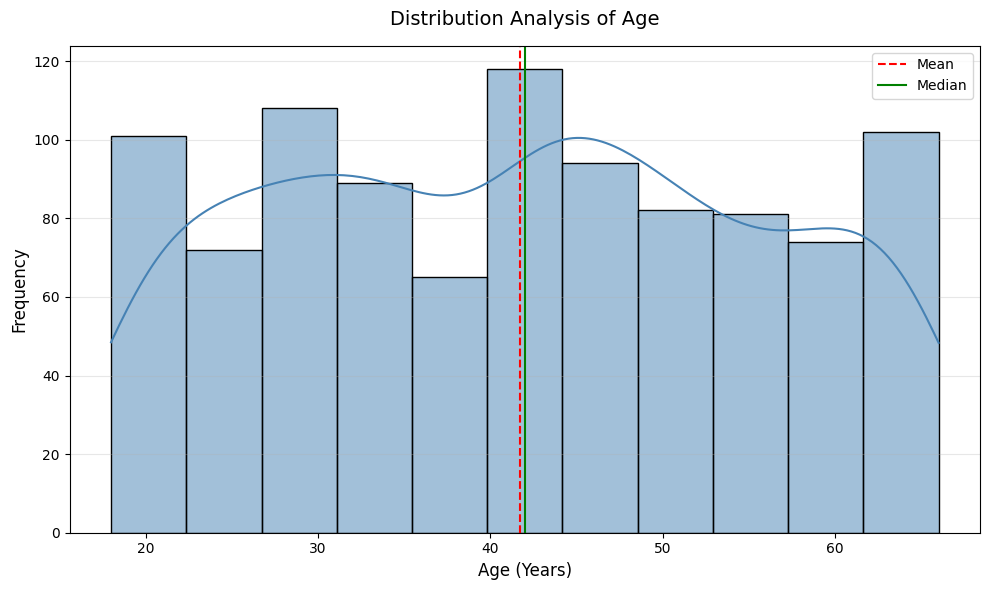

In [ ]:
# Execution of Age Distribution
plot_distribution(df, 'Age')

The chart shows the age distribution of the population. The KDE plot has three peaks: young adults (18–22), middle-aged adults (30–40), and seniors(55-66). While the mean and median are nearly equal, the distribution is symmetric but multimodal. This lack of normality suggests a linear model may not predict premiums accurately for all three groups.

In [ ]:
# Function for Boxplots

def plot_boxplot(data, column, color = 'steelblue'):
  """Generates a formatted boxplot with a median line."""
  plt.figure(figsize =(10,6))

  #Plotting
  boxplt = sns.boxplot(data[column], color=color)

  #Adding Statistical Context
  plt.axhline(data[column].median(), color='green', linestyle='--', label='Median')

  # Formal Formatting
  plt.title(f'Distribution Boxplot of {column}', fontsize=14, pad=15)
  plt.xlabel('')
  plt.ylabel(f'{column}', fontsize = 12)
  plt.legend()
  plt.grid(axis='y', alpha =0.3)

  plt.tight_layout()
  plt.show()

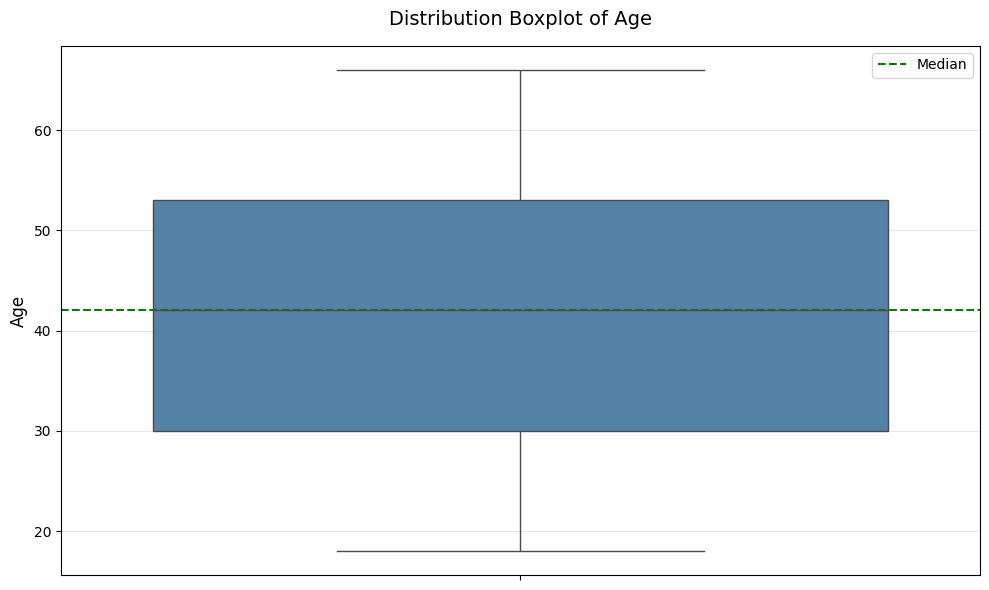

In [ ]:
#Execution of Age Boxplot

plot_boxplot(df, 'Age')

The boxplot indicates the absence of outliers. Most customers are in the age group between 30  years and 53 years. This is in line with our previous age distribution histogram, which indicats the mean at around 42 years.

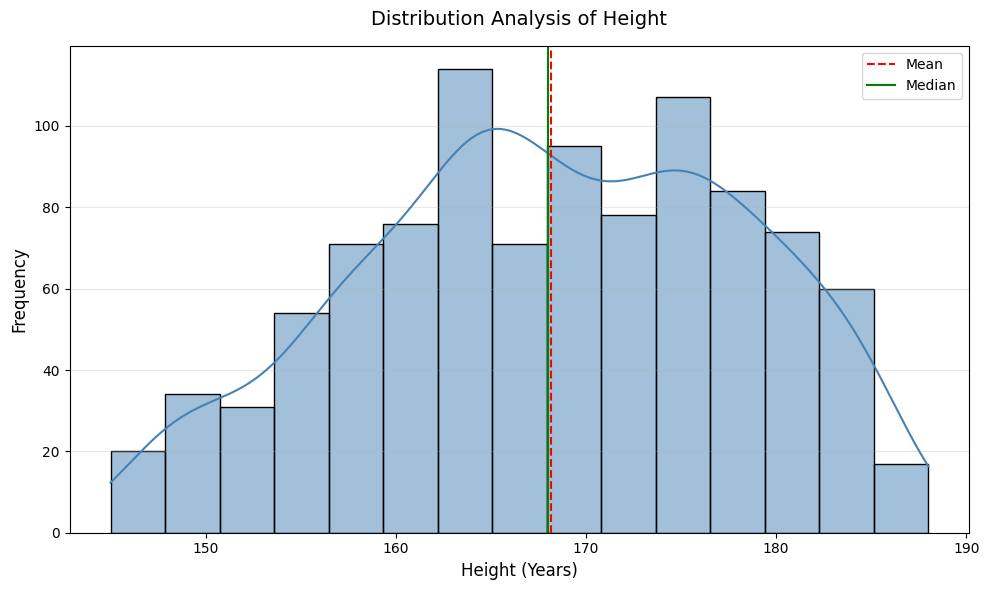

In [ ]:
# Execution of height Distribution
plot_distribution(df, 'Height')


The chart above illustrates the distribution of height. The mean and median are almost equat at 167cm indicating a symmetric distribution. But the distribution is not normal because the graph is showing two peaks.

A linear model may not capture the premium price accurately due to the lack of normality.

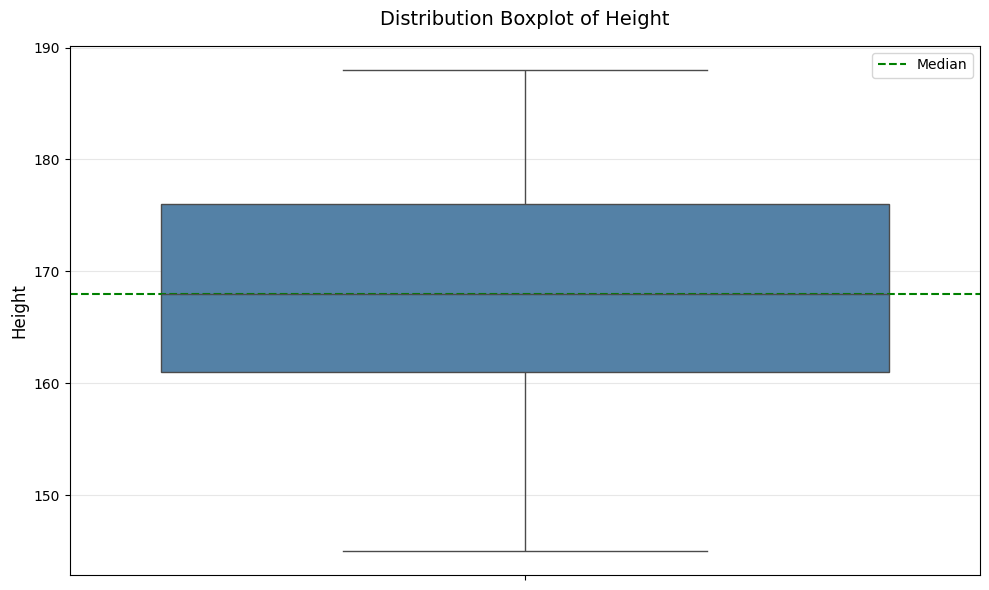

In [ ]:
plot_boxplot(df, 'Height')

The boxplot of the height feature shows us most customers heights are between IQR rannge - 160cm and 177cm. There are no extreme values in this feature and thus we dont have outliers.

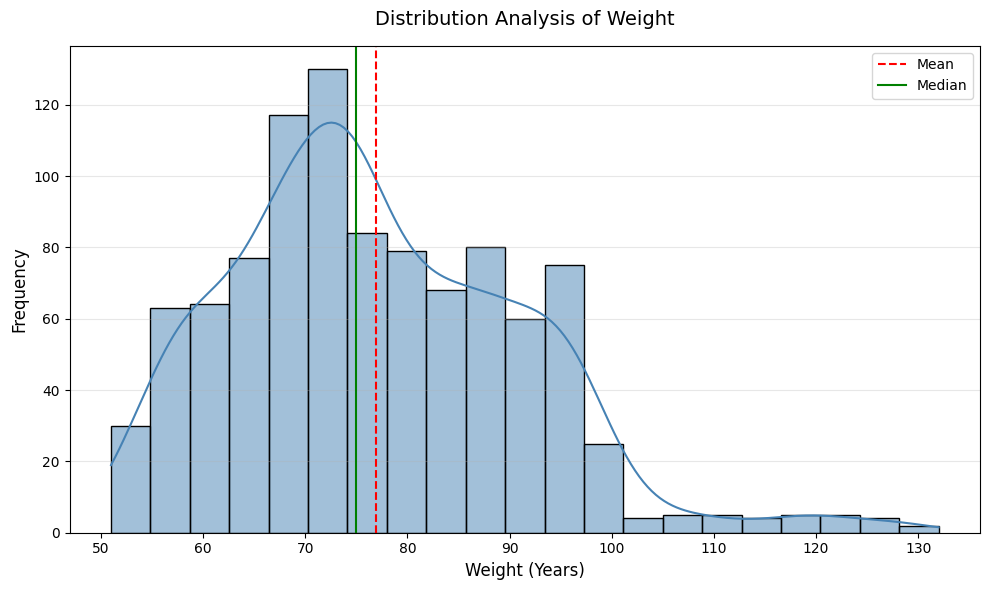

In [ ]:
#distribution of Weight

plot_distribution(df, 'Weight')

The chart shows the weight distribution. The mean (77kg) is higher than the median (75kg), which indicates a right skew. Weights above 100kg are likely outliers because the IQR ends at 88kg. These high values pull the mean toward the right tail, distorting the normality of the distribution.

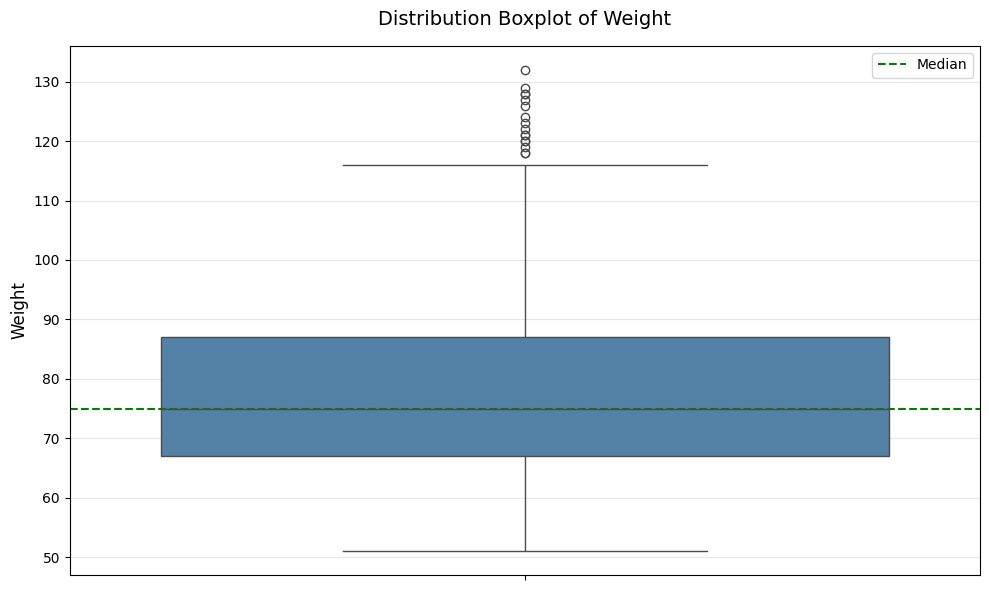

In [ ]:
plot_boxplot(df, 'Weight')

From the chart above - Boxplot of Weight. Most customers weigh between 67kg and 88kg, which is in line with the histogram for weights. The median is at around 75kg. There is evidence to assume there are outliers in this feature.

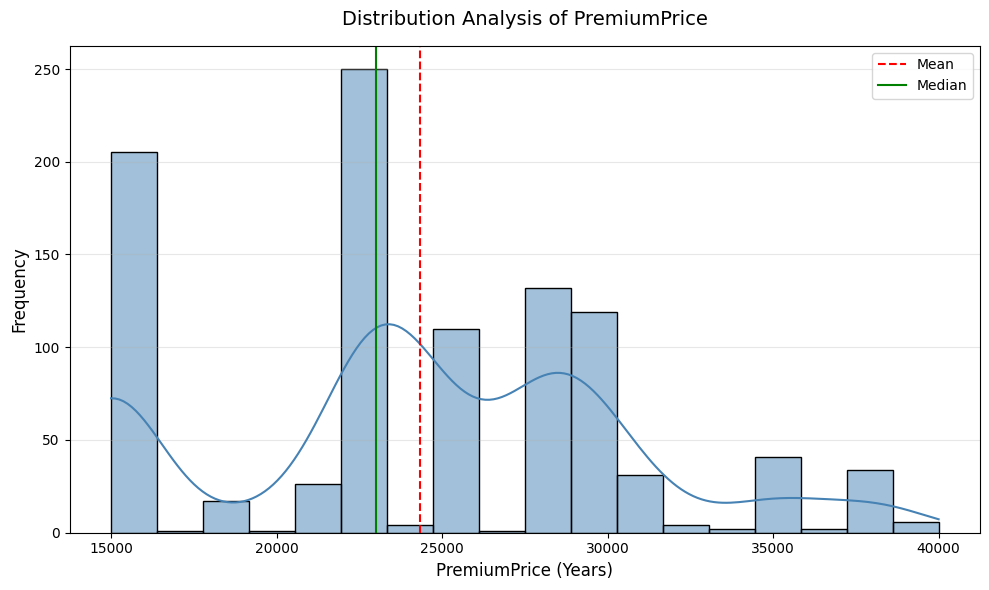

In [ ]:
#Distribution of Premium Price
plot_distribution(df, 'PremiumPrice')

The graph above illustrates the distribution of premium paid by customers. The mean is around Rs24000 and median around Rs23000, indicating a right skewed distribution. The kde is multimodal with distinct gaps in premiums prices. This indicates that the company is using pricing slabs while deciding premius of products.

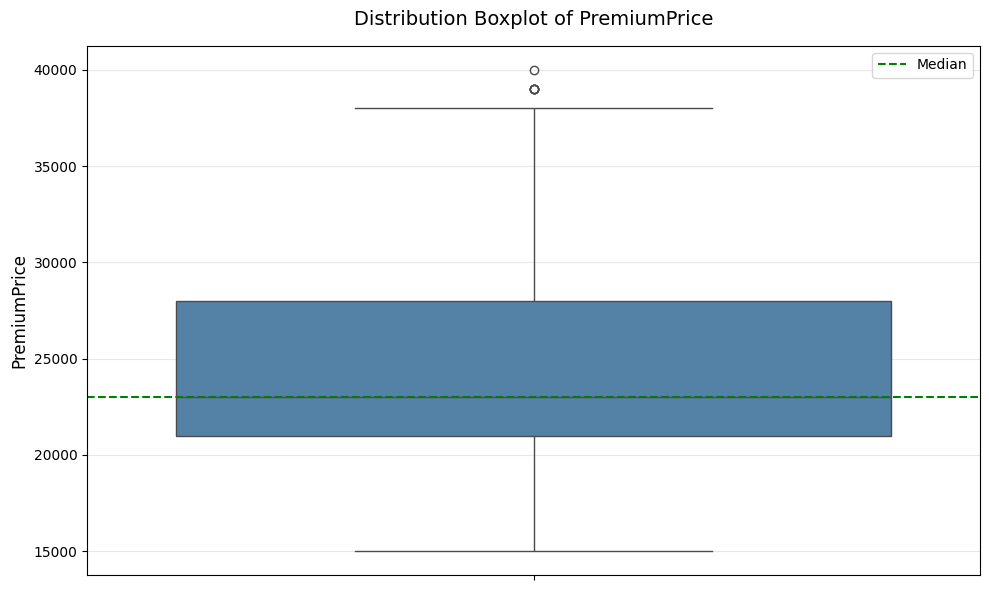

In [ ]:
plot_boxplot(df, 'PremiumPrice')

This boxplot shows the distribution of Premium Prices. The middle 50% of customers pay between Rs 21,000 and Rs 28,000. There is clear evidence of outliers at the higher end of the scale (above Rs 38,000). We will use the IQR method in the next steps to mathematically confirm these values.

In [ ]:
binary_columns = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'KnownAllergies', 'HistoryOfCancerInFamily']

print('Counts for Binary Features:')
for col in binary_columns:
    print(f'\n--- {col} ---')
    print(df[col].value_counts().sort_index())

print('\n--- NumberOfMajorSurgeries ---')
print(df['NumberOfMajorSurgeries'].value_counts().sort_index())

Counts for Binary Features:

--- Diabetes ---
Diabetes
0    572
1    414
Name: count, dtype: int64

--- BloodPressureProblems ---
BloodPressureProblems
0    524
1    462
Name: count, dtype: int64

--- AnyTransplants ---
AnyTransplants
0    931
1     55
Name: count, dtype: int64

--- AnyChronicDiseases ---
AnyChronicDiseases
0    808
1    178
Name: count, dtype: int64

--- KnownAllergies ---
KnownAllergies
0    774
1    212
Name: count, dtype: int64

--- HistoryOfCancerInFamily ---
HistoryOfCancerInFamily
0    870
1    116
Name: count, dtype: int64

--- NumberOfMajorSurgeries ---
NumberOfMajorSurgeries
0    479
1    372
2    119
3     16
Name: count, dtype: int64


The table above gives us the value counts of the binary and ordinal features. We can infer that Diabetes and Blood Pressure problems have balanced data. While the rest of the features are heavily imbalanced.

Like, in number of major surgeries column - "3" surgeries has only 16 data points. Data with imbalanced features will not give us accurate results. We will review these further in the following steps and make a informed decision..

##Bivariate Analysis

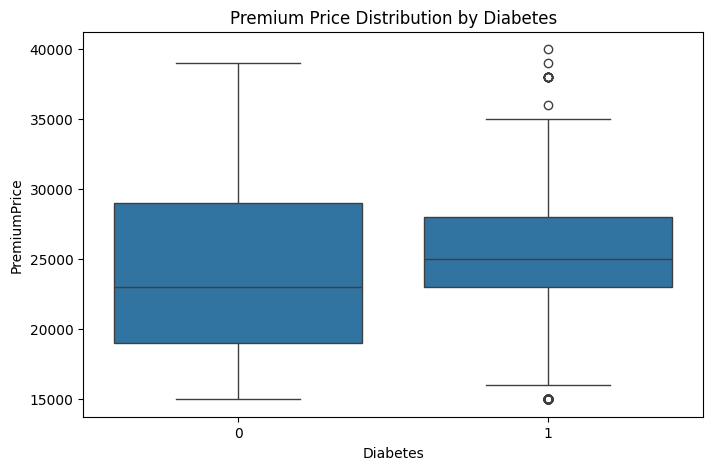

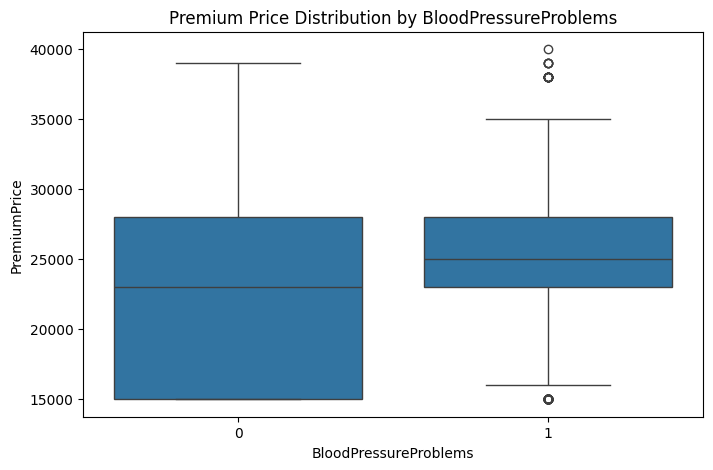

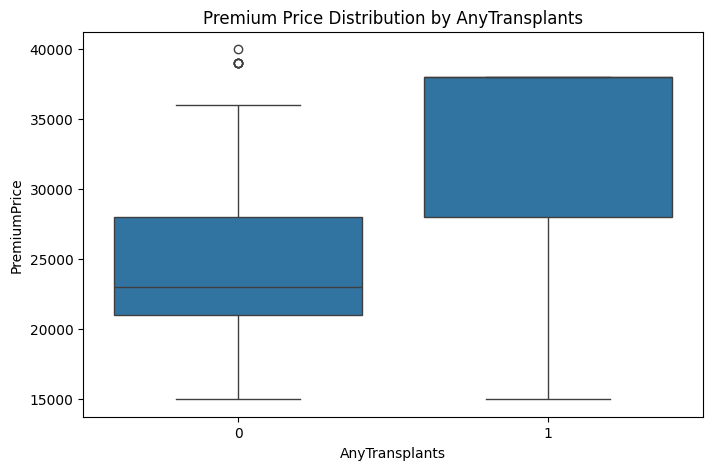

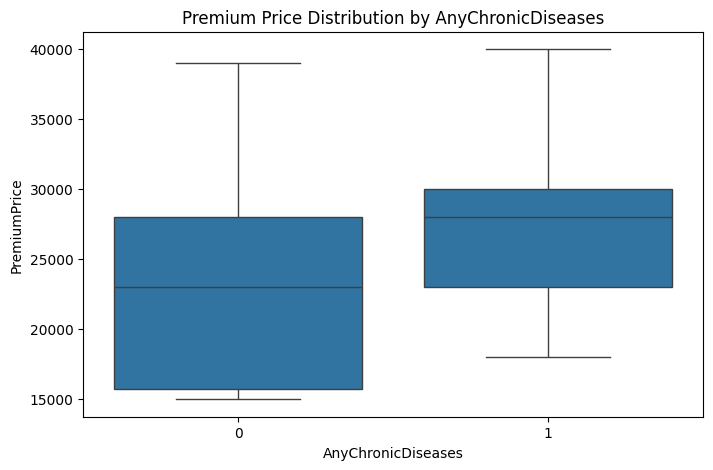

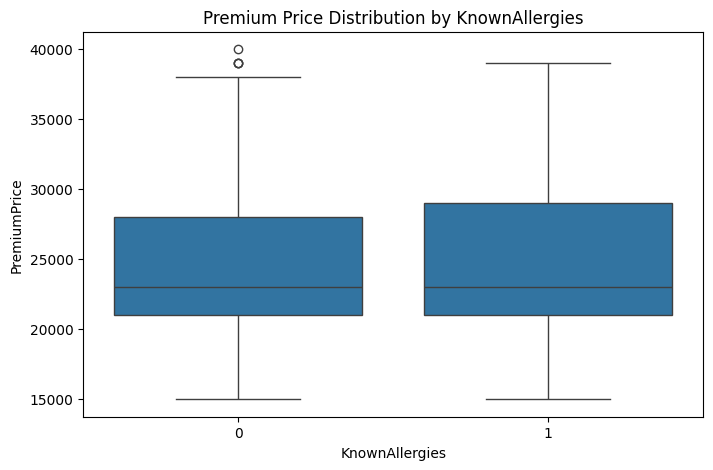

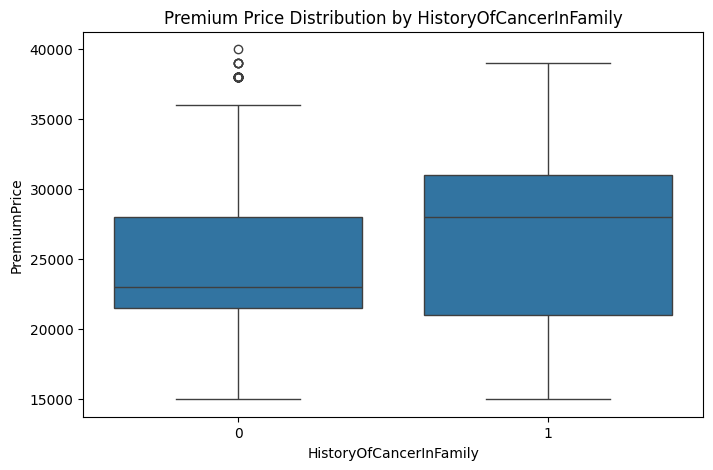

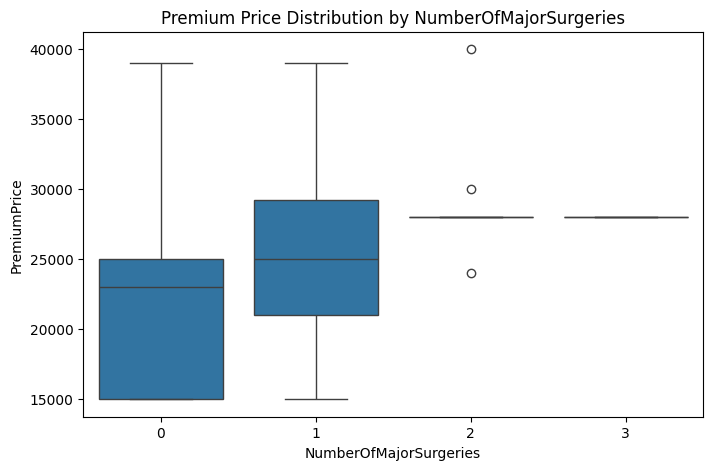

In [ ]:
# Boxplots for analysis of Categorical - Categorical - Numerical features

binary_columns_bivariate = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'KnownAllergies', 'HistoryOfCancerInFamily','NumberOfMajorSurgeries']

for col in binary_columns_bivariate:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=col, y='PremiumPrice', data=df)
    plt.title(f'Premium Price Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('PremiumPrice')
    plt.show()

Inference from above bivariate boxplots :

1. Diabetes : The data suggests most customers without diabates pay premium between Rs19000 and Rs27000. While those with diabetes pay between Rs24000 and Rs28000. The medians of both groups are close to each other at about Rs24000. The gap in 25th percentile between the two group suggests people without diabetes pays less premium if other values also have the same trend. The data also shows outliers above the 75th quartile. We will confirm this mathematically using IQR method before takinf decsion on it.


2. Blood Pressure : The illustration above indicates the effect blood pressure problems has on the premium price. Though the median is around Rs23000 to Rs29000, the floor level of premium price of customer without blood pressure is at Rs15000. There seems to be outliers that are indicated in the chart. We shall confirm them using iQR method in next steps. .


3. AnyTransplants : The chart shows a clear price jump for customers with a transplant history. Most customers without transplants pay between Rs 21,000 and Rs 27,000. In contrast, those with transplants pay significantly more, ranging from Rs 27,000 to Rs 37,000. There is a large gap between the groups: the "floor" price for the transplant group is higher than the "ceiling" price for 75% of the non-transplant group. This suggests that a transplant history is a major driver of high premiums.

4. Any Chronic Disease : The data suggests customers without any chronic disease pays between Rs15000 and Rs27000. While those with them pays between Rs24000 and Rs30000. There is large gap between the two group's 25th percentile values. Again shows the effect of chronic desease to premium prices.


5. Known Allergies : The data indicates both groups pay between Rs21000 and Rs27000 premium price. This suggests this is not a significant predictor of  premium prices.

6. History of Cancer in the Family : The chart shows that a family history of cancer leads to a moderate increase in premiums. The median price for Group 1 (Rs 27,000) is slightly higher than for Group 0 (Rs 23,000). While the interquartile ranges (the boxes) overlap, the "floor" price for those with a family history is higher. This suggests that family history is a contributing risk factor, but it does not cause the massive price jumps seen in other categories.


7. Number of Major Surgeries :The chart illustrates how the number of major surgeries impacts premiums. There is a significant price jump between having no surgeries and having one surgery. Customers with no surgeries start at a "floor" of Rs 15,000, while those with one or more surgeries start at Rs 21,000. Interestingly, after the first surgery, the premium price remains relatively stable. Due to the small amount of data for 2 and 3 surgeries, these categories should be treated with caution.

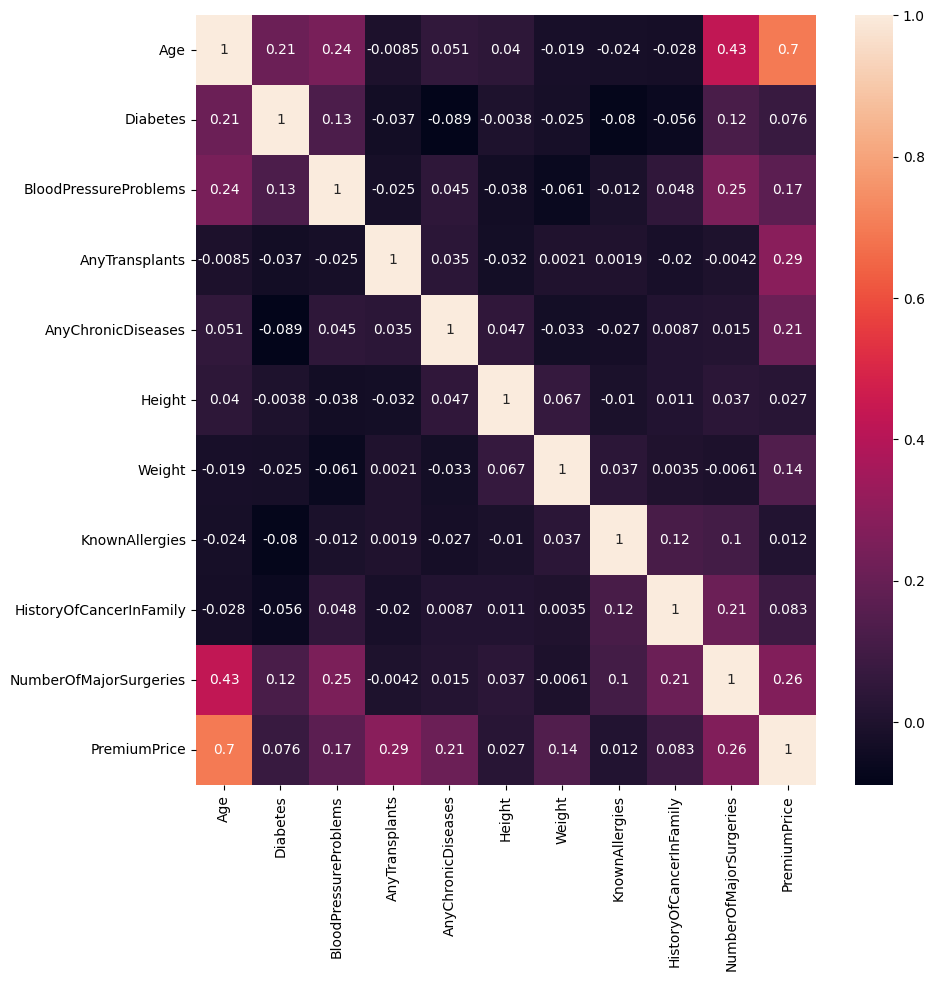

In [ ]:
#Heatmap of all variables

plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

The Heat Map confirms that Age has the strongest linear relationship with premiums (0.70). While Transplants and Major Surgeries show moderate correlations (0.29 and 0.26), other health factors like Diabetes and Blood Pressure appear surprisingly low. This is likely because correlation measures linear strength across the whole dataset, whereas our bivariate analysis showed that these health factors act more like "price floors" rather than a steady linear increase.

#Multivariate Analysis

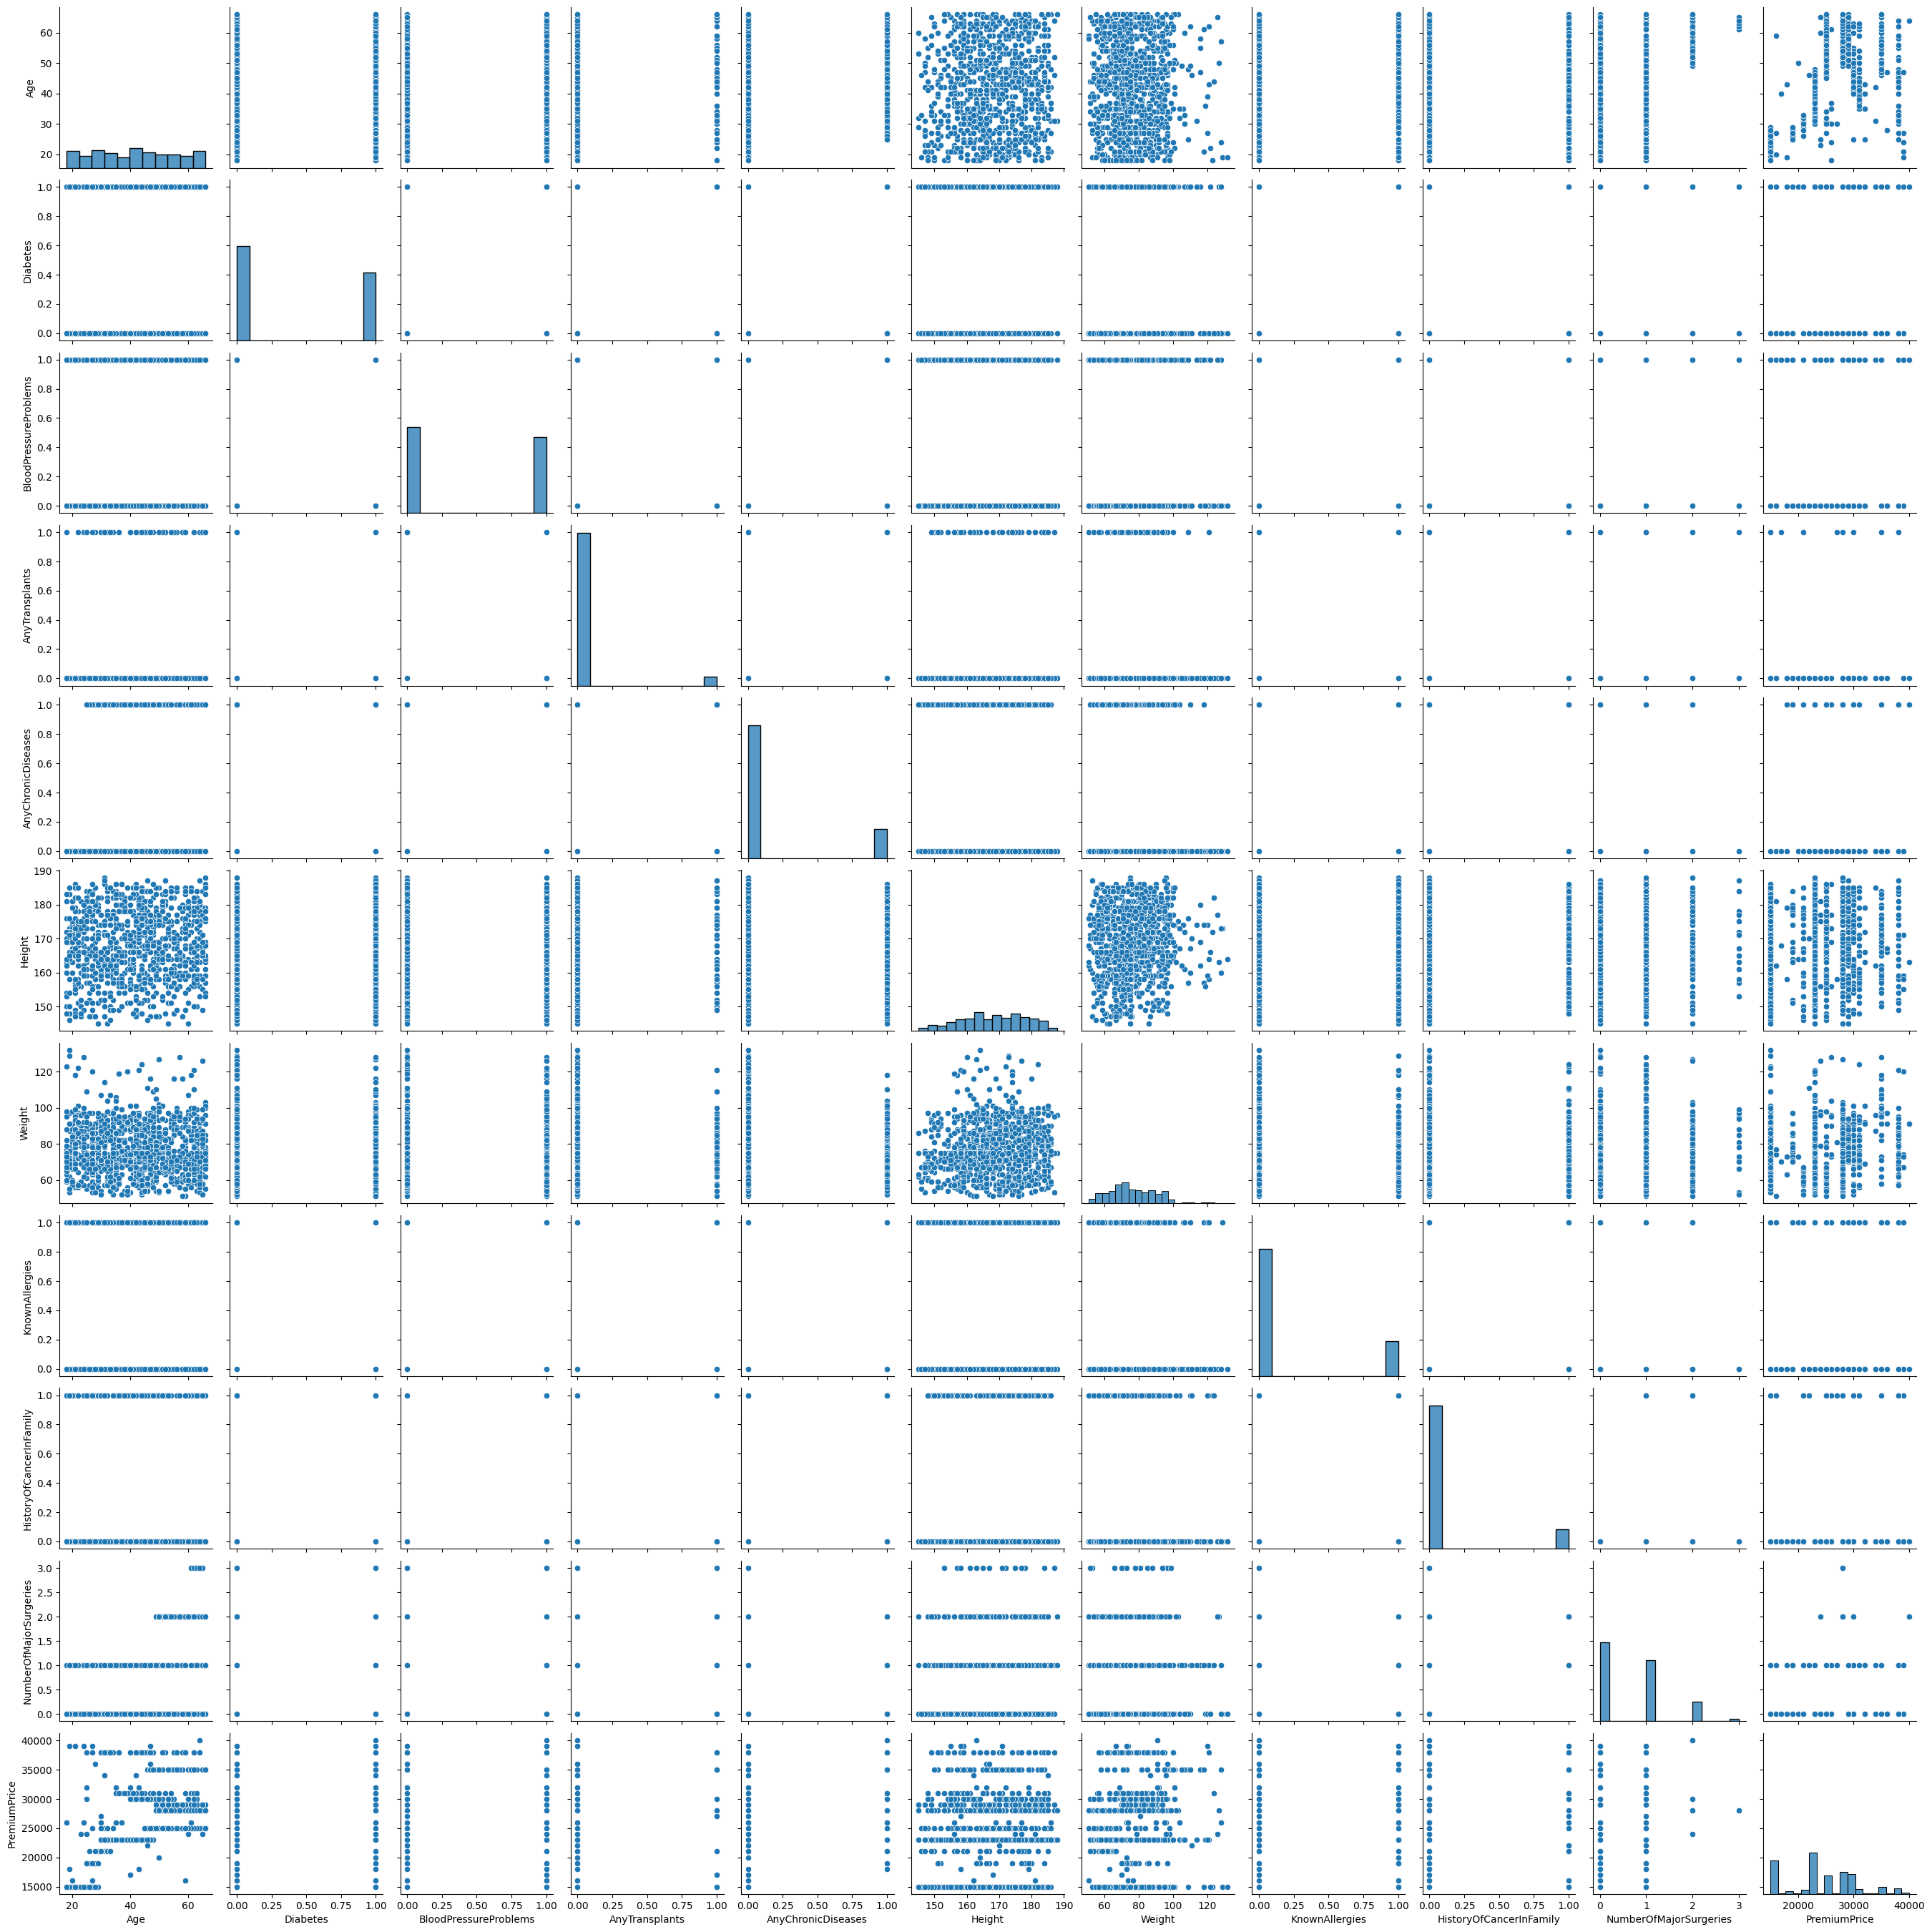

In [ ]:

#Pairplot betweena all variables.
sns.pairplot(df)
plt.show()

The pair plot shows the relationship between all variables. Age and Premium Price show a strong upward trend, but the high-density horizontal lines suggest a step-wise pricing model. This means prices stay flat for certain age brackets before jumping to the next level. Other features do not show a clear linear pattern with price, suggesting they act as secondary adjustments rather than primary pricing drivers.

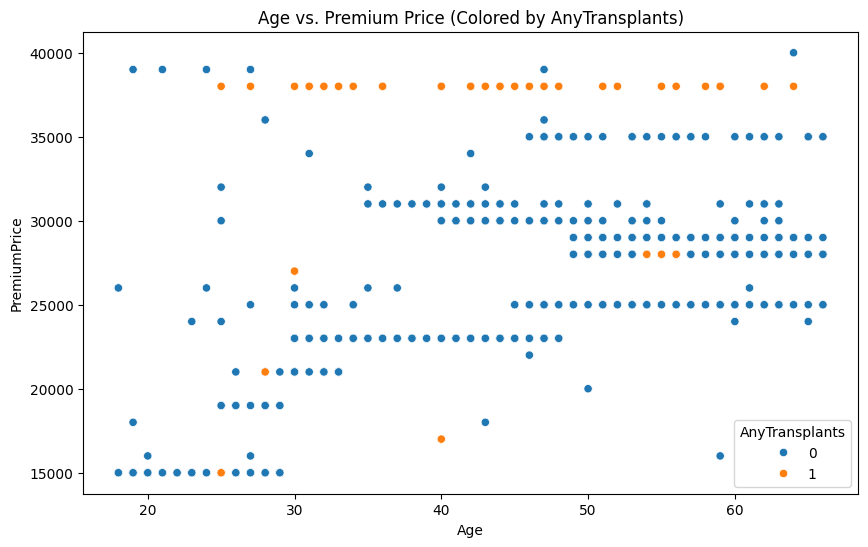

In [ ]:
#Age vs. Premium (Colored by AnyTransplants):

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='PremiumPrice', hue='AnyTransplants', data=df)
plt.title('Age vs. Premium Price (Colored by AnyTransplants)')
plt.xlabel('Age')
plt.ylabel('PremiumPrice')
plt.show()

The above chart represents distribution between Age, Premium Price and Transplantation. The premium price is over Rs35000 for customers that has had atleast 1 transplantation. The premium at this level is the highest amongst all groups in this dataset. Group of customers in the "1 transplant" category is just 55 in number(output from value_count function), which is a small population considering the total customers is around 960. This imbalance can lead to errors in predicting tjhe right price.

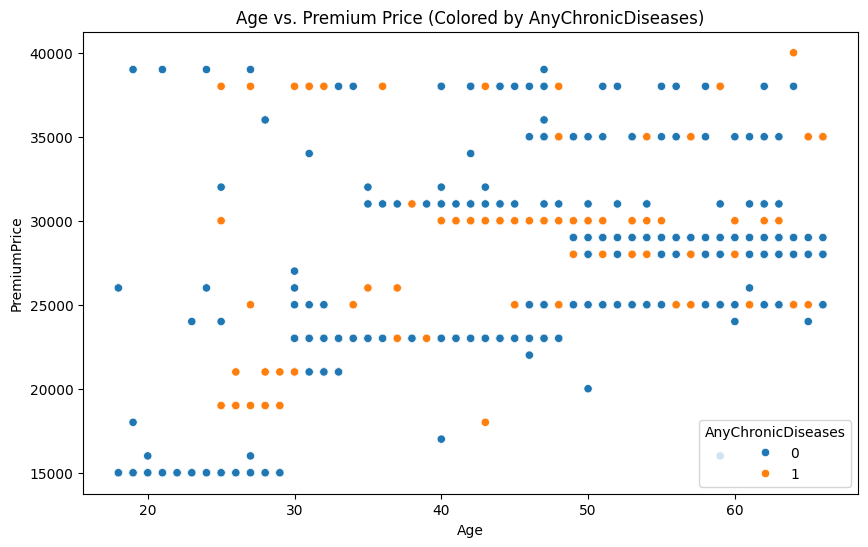

In [ ]:
#Premium Price vs. Age (Colored by AnyChronicDiseases):

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='PremiumPrice', hue='AnyChronicDiseases', data=df)
plt.title('Age vs. Premium Price (Colored by AnyChronicDiseases)')
plt.xlabel('Age')
plt.ylabel('PremiumPrice')
plt.show()

The above chart represents the distribution between Age, Premium Price and Chronic Disease. The premium price is varies across disease and age feature. The disease is probably pushing the premium up by some margin, but not the driver. The count of poupation with chronic disease is 178, that is approx 18% of the total population.

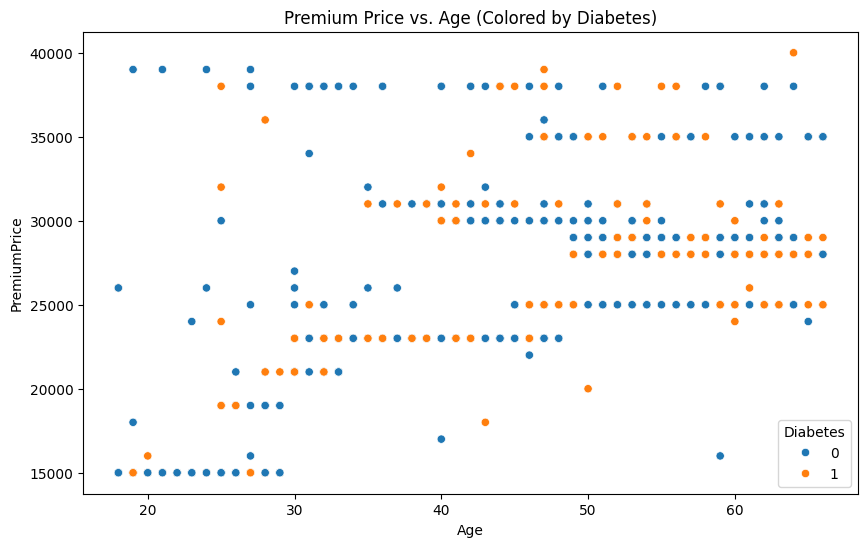

In [ ]:
#Age vs. Premium Price (Colored by Diabetes):

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='PremiumPrice', hue='Diabetes', data=df)
plt.title('Premium Price vs. Age (Colored by Diabetes)')
plt.xlabel('Age')
plt.ylabel('PremiumPrice')
plt.show()

The above chart represents the distribution between Age, Premium Price and diabetes. The total population with diabetes is 414, that is around 40% of the total population. As per the heatmap, diabetes does not impact the Premium price too much with low correlation of 0.076. But this chart shows there is pattern - linear relationship. We can see stepped increments in premium as age increases. Also we can note the population with diabetes also increases with age. We will consider this inference as we go forward in this analysis.

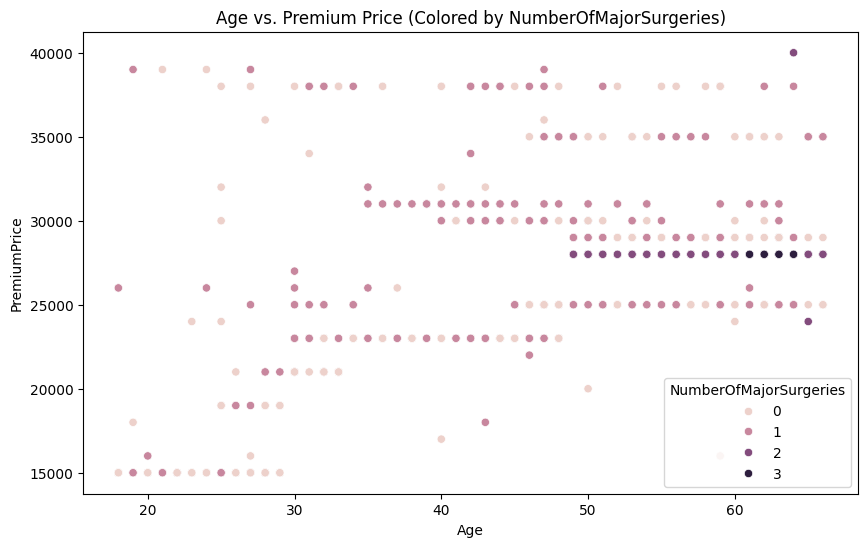

In [ ]:
#Age vs. Premium (Colored by Number of Major Surgeries):

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='PremiumPrice', hue='NumberOfMajorSurgeries', data=df)
plt.title('Age vs. Premium Price (Colored by NumberOfMajorSurgeries)')
plt.xlabel('Age')
plt.ylabel('PremiumPrice')
plt.show()


This chart illustrates the distribution between Prmium Price, Age and Number of major surgeries. Note that the population with two or more surgeries are capped below the Rs30000 mark. But we can see population without surgery and with only 1 surgery to have premium price over the Rs30000 mark. This is counterintuitive to the logic. We will further analyze this to understand the pricing in the next steps.

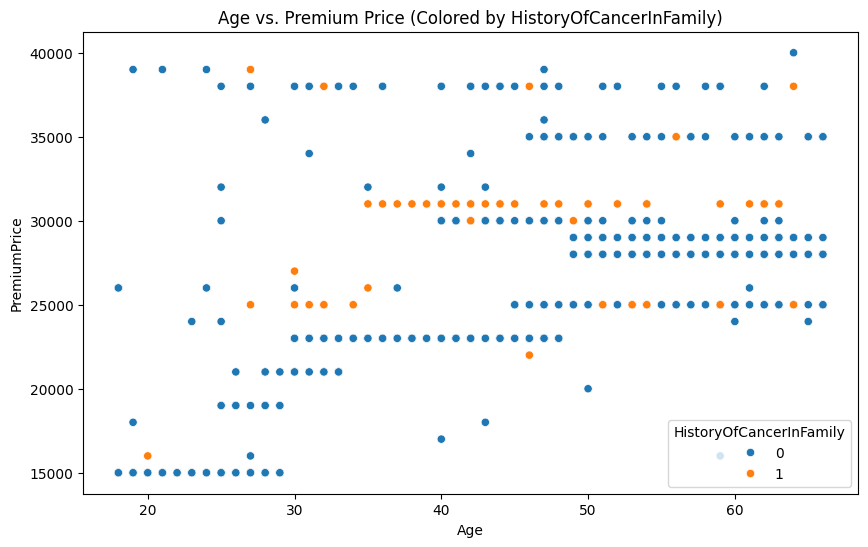

In [ ]:
#Age vs. Premium (Colored by Number of HistoryOfCancerInFamily):

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='PremiumPrice', hue='HistoryOfCancerInFamily', data=df)
plt.title('Age vs. Premium Price (Colored by HistoryOfCancerInFamily)')
plt.xlabel('Age')
plt.ylabel('PremiumPrice')
plt.show()

The chart above indicates the distribution between Premium Price , Age and History of cancer in the family. Population with cancer in family is mostly at Rs30000 premium regardless of age. There are very few anamolies in population paying  a premium around Rs40000 and Rs25000.

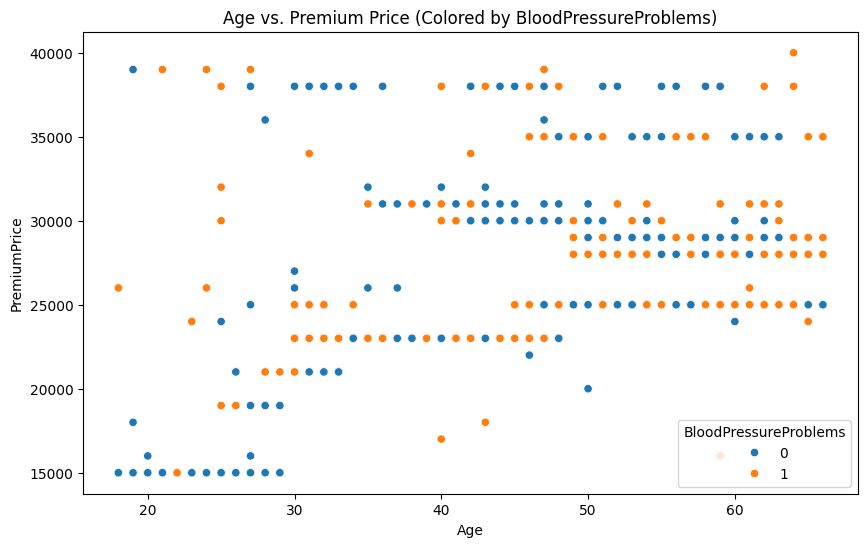

In [ ]:
#Age vs. Premium (Colored by BloodPressureProblems):

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='PremiumPrice', hue='BloodPressureProblems', data=df)
plt.title('Age vs. Premium Price (Colored by BloodPressureProblems)')
plt.xlabel('Age')
plt.ylabel('PremiumPrice')
plt.show()

The illustration above indicates the distribution between Premium price, Age and Blood pressure problems. The density of population with blood pressure is high beyond age 40 years and above Rs25000 premium.    

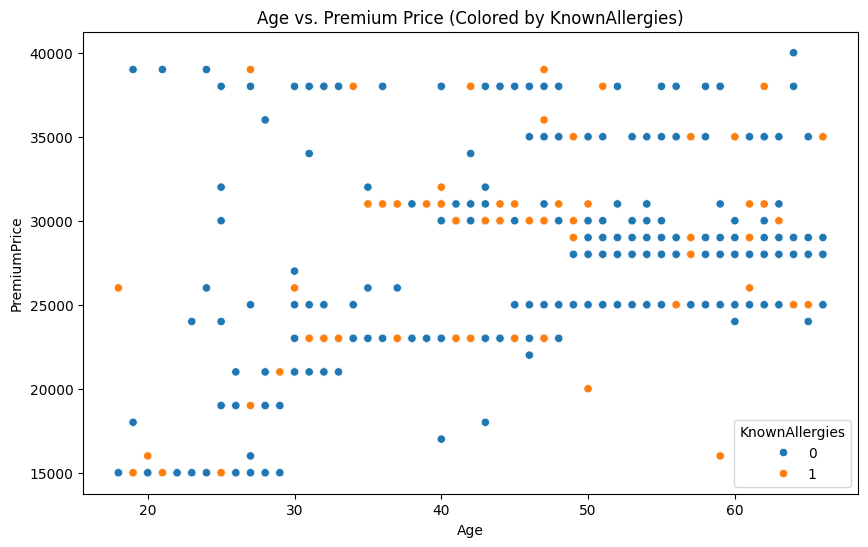

In [ ]:
#Age vs. Premium (Colored by KnownAllergies):

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='PremiumPrice', hue='KnownAllergies', data=df)
plt.title('Age vs. Premium Price (Colored by KnownAllergies)')
plt.xlabel('Age')
plt.ylabel('PremiumPrice')
plt.show()

The illustration above indicates the distribution between Premium price, Age and Known Allergies. The distribution is spread out for population with known allergies. This indicates the premium price is not necessarily affected by allergies.

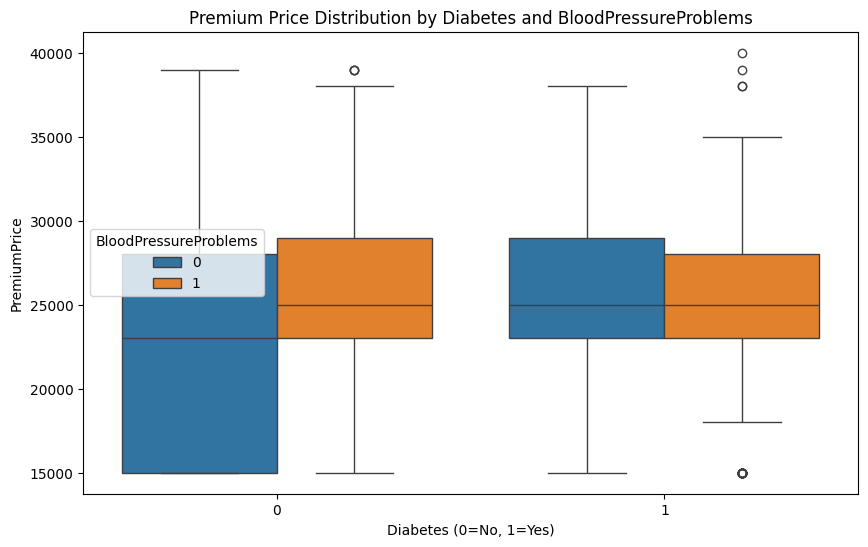

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes', y='PremiumPrice', hue='BloodPressureProblems', data=df)
plt.title('Premium Price Distribution by Diabetes and BloodPressureProblems')
plt.xlabel('Diabetes (0=No, 1=Yes)')
plt.ylabel('PremiumPrice')
plt.show()

The chart shows that having either Diabetes or Blood Pressure problems pushes the premium into a similar range (Rs 22,000 to Rs 30,000). Interestingly, having both conditions does not increase the median price further. The "Diabetes Only" group actually maintains a median slightly higher than or equal to the "Both" group. This indicates that these risks do not simply add up; the pricing seems to hit a "plateau" once a major chronic condition is present.

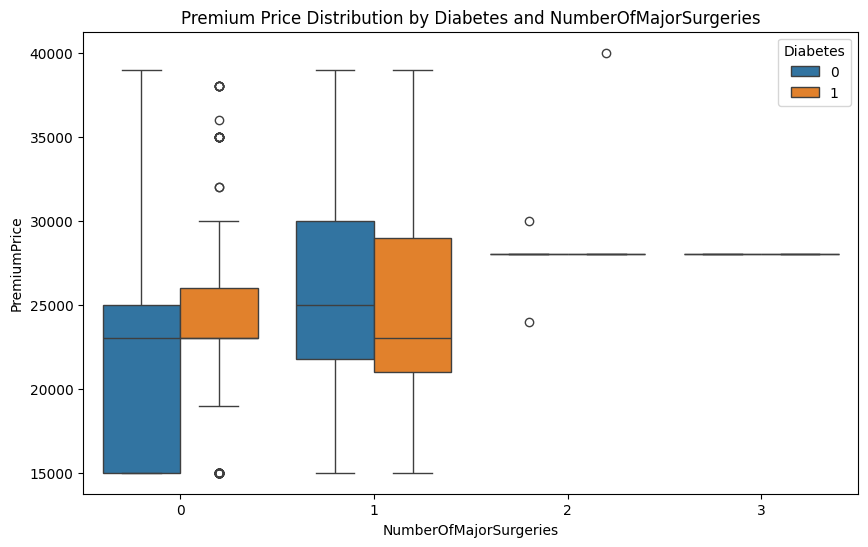

In [ ]:
#Premium Price Distribution by Diabetes and Number Of Major Surgeries

plt.figure(figsize=(10, 6))
sns.boxplot(x='NumberOfMajorSurgeries', y='PremiumPrice', hue='Diabetes', data=df)
plt.title('Premium Price Distribution by Diabetes and NumberOfMajorSurgeries')
plt.xlabel('NumberOfMajorSurgeries')
plt.ylabel('PremiumPrice')
plt.show()

This chart examines the interaction between Diabetes and the Number of Major Surgeries. For customers with no surgery history, diabetes significantly narrows the price range to a tight band between Rs 24,000 and Rs 26,000. For those with one surgery, the premium ranges are similar regardless of diabetes status. Surprisingly, the median premium for those with one surgery and no diabetes (Rs 25,000) is slightly higher than for those with diabetes (Rs 24,000). As noted before, data for two or more surgeries is too limited to draw firm conclusions.

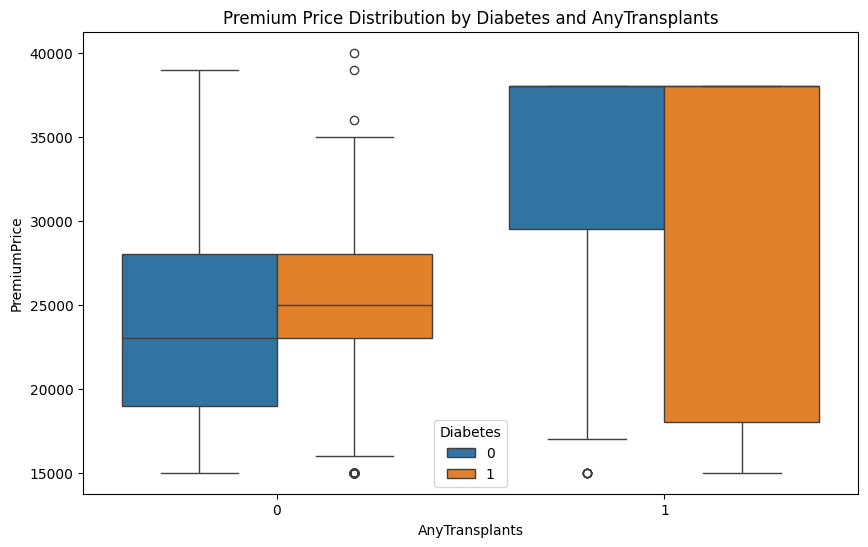

In [ ]:
#Premium Price Distribution by Diabetes and AnyTransplants

plt.figure(figsize=(10, 6))
sns.boxplot(x='AnyTransplants', y='PremiumPrice', hue='Diabetes', data=df)
plt.title('Premium Price Distribution by Diabetes and AnyTransplants')
plt.xlabel('AnyTransplants')
plt.ylabel('PremiumPrice')
plt.show()

This distribution confirms that transplant history is the primary driver of top-tier premiums, consistently exceeding Rs 35,000. In the absence of a transplant, diabetes increases the median premium and narrows the price range. However, for transplant patients, diabetes status provides no additional price increase, indicating that the pricing model caps the premium once the highest risk category is reached.

The sample size for tranplant = 1 is very small.

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

print("Outliers detection using IQR method:")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n--- {col} ---")
    print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")
    if not outliers.empty:
        print("Outliers (first 5 rows):\n", outliers[[col]].head())


Outliers detection using IQR method:

--- Age ---
Q1: 30.0, Q3: 53.0, IQR: 23.0
Lower Bound: -4.5, Upper Bound: 87.5
Number of outliers: 0

--- Diabetes ---
Q1: 0.0, Q3: 1.0, IQR: 1.0
Lower Bound: -1.5, Upper Bound: 2.5
Number of outliers: 0

--- BloodPressureProblems ---
Q1: 0.0, Q3: 1.0, IQR: 1.0
Lower Bound: -1.5, Upper Bound: 2.5
Number of outliers: 0

--- AnyTransplants ---
Q1: 0.0, Q3: 0.0, IQR: 0.0
Lower Bound: 0.0, Upper Bound: 0.0
Number of outliers: 55
Outliers (first 5 rows):
     AnyTransplants
14               1
26               1
39               1
73               1
79               1

--- AnyChronicDiseases ---
Q1: 0.0, Q3: 0.0, IQR: 0.0
Lower Bound: 0.0, Upper Bound: 0.0
Number of outliers: 178
Outliers (first 5 rows):
     AnyChronicDiseases
3                    1
4                    1
16                   1
28                   1
29                   1

--- Height ---
Q1: 161.0, Q3: 176.0, IQR: 15.0
Lower Bound: 138.5, Upper Bound: 198.5
Number of outliers: 0

--- W

The output of the above code block gives us details of outliers using the IQR method on all the features available to us.

There are features that are binary outputs.  We cannot get any evidence suggesting there are outliers in those groups.

The features - Weight, height , age and premium price have very few outliers within single digits. The overall rows length is 900 odd rows. Keeping this in mind we will not using any outlier treatment on the data set.

##Feature Engineering

In [ ]:
#Create BMI index

df['BMI'] = round(df['Weight'] / (df['Height']/100)**2,2)

In [ ]:
#Create Total Risk Index

df['TotalRisk'] = df['Diabetes'] + df['BloodPressureProblems'] + df['AnyTransplants'] + df['AnyChronicDiseases'] + df['KnownAllergies'] + df['HistoryOfCancerInFamily'] + df['NumberOfMajorSurgeries']

In [ ]:
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,TotalRisk
0,45,0,0,0,0,155,57,0,0,0,25000,23.73,0
1,60,1,0,0,0,180,73,0,0,0,29000,22.53,1
2,36,1,1,0,0,158,59,0,0,1,23000,23.63,3
3,52,1,1,0,1,183,93,0,0,2,28000,27.77,5
4,38,0,0,0,1,166,88,0,0,1,23000,31.93,2


<Axes: xlabel='BMI', ylabel='Count'>

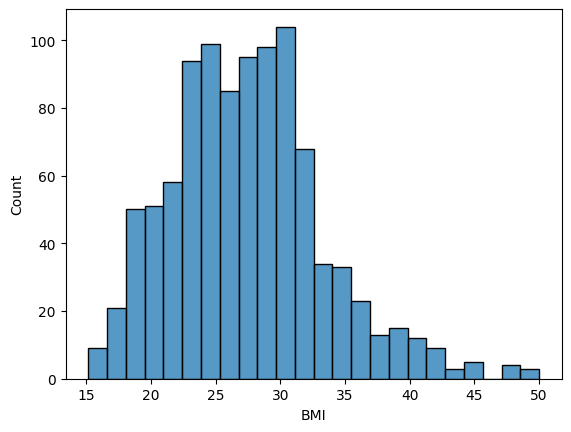

In [ ]:
sns.histplot(df['BMI'])

<Axes: xlabel='TotalRisk', ylabel='Count'>

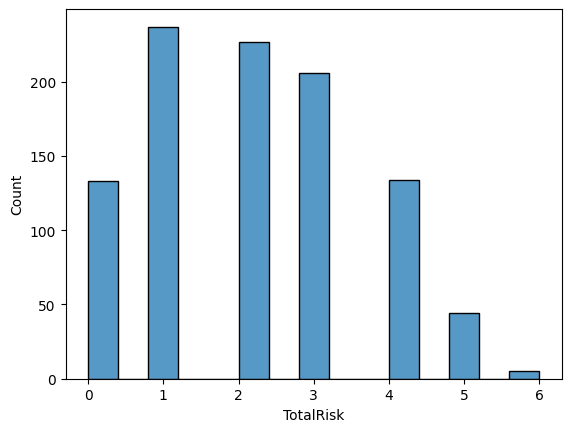

In [ ]:
sns.histplot(df['TotalRisk'])

<Axes: xlabel='BMI', ylabel='PremiumPrice'>

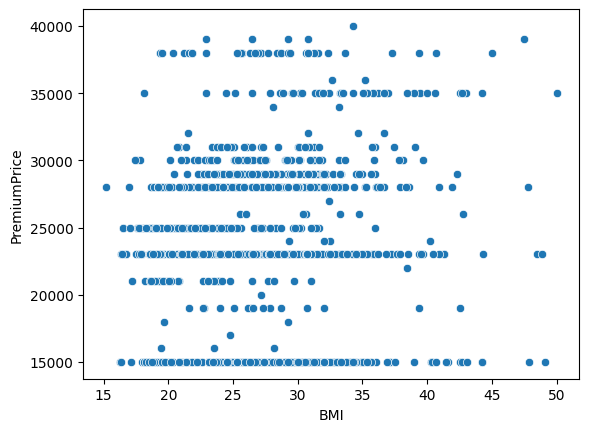

In [ ]:
sns.scatterplot(x='BMI', y='PremiumPrice', data=df)

##Hypothesis Testing


Question 1

Null Hypothesis : There is no significant correlation  between Age and Premium Price.

Alternate Hypothesis : There is significant correlation  between Age and Premium Price.


In [ ]:
#Code for Pearson Correlation and P-value

from scipy import stats

r_value, p_value = stats.pearsonr(df['Age'], df['PremiumPrice'])

print(f"Pearson Correlation Coefficient (r) : {r_value: .4f}")
print(f"P-value : {p_value:.4f}")


#Checking significance level

alpha = 0.05

if p_value < alpha:
  print("Conclusion: Reject the Null Hypothesis. There is a significant correlation.")
else:
  print("Conclusion: Fail to Reject the Null Hypothesis. No significant correlation found.")



Pearson Correlation Coefficient (r) :  0.6975
P-value : 0.0000
Conclusion: Reject the Null Hypothesis. There is a significant correlation.


In [ ]:
# Calculate Spearman Rank Correlation
rho, p_val_spearman = stats.spearmanr(df['Age'], df['PremiumPrice'])

print(f"Spearman Correlation (rho): {rho:.4f}")
print(f"Spearman P-value: {p_val_spearman:.4e}")

Spearman Correlation (rho): 0.7391
Spearman P-value: 4.8928e-171


Question 1 Conclusion:

Reject the Null Hypothesis. There is a significant correlation between Age and Premium Price.

Question 2

Null Hypothesis : The number of major surgeries does not significantly affect the Premium Price.

Alternate Hypothesis : The number of major surgeries significantly affect the Premium Price

In [ ]:
# Using One Way ANOVA Test for testing the effect of Surgeries on Premium Price

#Prepare groups for the test

group_1 = df[df['NumberOfMajorSurgeries'] == 0]['PremiumPrice']
group_2 = df[df['NumberOfMajorSurgeries'] == 1]['PremiumPrice']
group_3 = df[df['NumberOfMajorSurgeries'] == 2]['PremiumPrice']
group_4 = df[df['NumberOfMajorSurgeries'] == 3]['PremiumPrice']


# Oneway ANOVA test(parametric)

f_stat, p_val_anova = stats.f_oneway(group_1, group_2, group_3, group_4)

print(" --------- One-Way ANOVA Test ---------")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val_anova:.4e}")




 --------- One-Way ANOVA Test ---------
F-statistic: 26.1354
P-value: 2.8712e-16


In [ ]:
#Perform Kruskal-Wallis (Non Parametric)

h_stat,p_val_kruskal = stats.kruskal(group_1, group_2, group_3, group_4)

print("\n--- Kruskal-Wallis Test ---")
print(f"H-Statistic: {h_stat:.4f}")
print(f"P-value: {p_val_kruskal:.4e}")




--- Kruskal-Wallis Test ---
H-Statistic: 93.8128
P-value: 3.3223e-20


In [ ]:
# Checking significane levels for oneway anova

alpha = 0.05

if p_val_anova < alpha:
  print("Reject the Null Hypothesis. The number of major surgeries significantly affect the Premium Price.")

else :
  print("Fail to Reject the Null Hypothesis.")

Reject the Null Hypothesis. The number of major surgeries significantly affect the Premium Price.


In [ ]:
# Checking significane levels for kruskal Wallis

alpha = 0.05

if p_val_kruskal < alpha:
  print("Reject the Null Hypothesis. The number of major surgeries significantly affect the Premium Price.")

else :
  print
  print("Fail to Reject the Null Hypothesis.")

Reject the Null Hypothesis. The number of major surgeries significantly affect the Premium Price.


Question 2 Conclusion :

One-way ANOVA and Kruskal Wallis tests failed to reject the null hypothesis.The number of major surgeries significantly affect the Premium Price.

Question 3

Null Hypothesis : The presence of diabetes does not significantly affect the Premium Price.

Alternate Hypothesis : The presence of diabetes significantly affect the Premium Price.

In [ ]:
# Split data into two grups - Diabetic and non-diabetic

diabetic = df[df['Diabetes'] == 1]['PremiumPrice']
non_diabetic = df[df['Diabetes'] == 0]['PremiumPrice']

# Perform the Two-Sample T-test

t_stat,p_val = stats.ttest_ind(diabetic, non_diabetic, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Decision Logic
if p_val < 0.05:
    print("Conclusion: Reject Null Hypothesis. Diabetes has a significant effect on Premium Price.")
else:
    print("Conclusion: Fail to Reject Null Hypothesis.")

T-Statistic: 2.4489
P-value: 1.4508e-02
Conclusion: Reject Null Hypothesis. Diabetes has a significant effect on Premium Price.


Question 3 Conclusion :

The two sample t test Rejected the null hypothesis. Diabetes has a significant effect on premium price.

Question 4

Null Hypothesis : The presence of blood pressure does not significantly affect the Premium Price.

Alternate Hypothesis : The presence of blood pressure significantly affect the Premium Price.



In [ ]:
# Split groups for Welsch's T-test and Mann-Whitney u
bp_yes = df[df['BloodPressureProblems'] == 1]['PremiumPrice']
bp_no = df[df['BloodPressureProblems'] == 0]['PremiumPrice']

# Parametric: Welch's T-test
t_stat, p_val_t = stats.ttest_ind(bp_yes, bp_no, equal_var=False)

# Non-Parametric: Mann-Whitney U (recommended for tiered data)
u_stat, p_val_u = stats.mannwhitneyu(bp_yes, bp_no)

print(f"T-test P-value: {p_val_t:.4e}")
print(f"Mann-Whitney P-value: {p_val_u:.4e}")

if p_val_t < 0.05:
    print("Conclusion: Reject Null Hypothesis. Blood Pressure has a significant effect on Premium Price.")
else:
    print("Conclusion: Fail to Reject Null Hypothesis.")

if p_val_u < 0.05:
    print("Conclusion: Reject Null Hypothesis. Blood Pressure has a significant effect on Premium Price.")
else:
    print("Conclusion: Fail to Reject Null Hypothesis.")


T-test P-value: 9.8135e-08
Mann-Whitney P-value: 3.0822e-08
Conclusion: Reject Null Hypothesis. Blood Pressure has a significant effect on Premium Price.
Conclusion: Reject Null Hypothesis. Blood Pressure has a significant effect on Premium Price.


Question 4 Conclusion

Both the test rejected the null hypothesis. Therefore Blood Pressure has a significant effect on Premium Price.

Question 5

Null Hypothesis : The presence of diabetes and blood pressure does not significantly affect the Premium Price.

Alternate Hypothesis : The presence of diabetes and blood pressure significantly affect the Premium Price.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols


# 'PremiumPrice ~ C(Diabetes) * C(BloodPressureProblems)'
# The '*' tells Python to look at individual effects AND the interaction
model = ols('PremiumPrice ~ C(Diabetes) * C(BloodPressureProblems)', data=df).fit()

# 2. Perform the Two-Way ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

# Conclusion
alpha = 0.05
print("\n--- ANOVA Test Conclusions ---")
if anova_table['PR(>F)']['C(Diabetes)'] < alpha:
    print("Reject Null Hypothesis for Diabetes: Diabetes significantly affects Premium Price.")
else:
    print("Fail to Reject Null Hypothesis for Diabetes: Diabetes does not significantly affect Premium Price.")

if anova_table['PR(>F)']['C(BloodPressureProblems)'] < alpha:
    print("Reject Null Hypothesis for BloodPressureProblems: Blood Pressure Problems significantly affect Premium Price.")
else:
    print("Fail to Reject Null Hypothesis for BloodPressureProblems: Blood Pressure Problems do not significantly affect Premium Price.")

if anova_table['PR(>F)']['C(Diabetes):C(BloodPressureProblems)'] < alpha:
    print("Reject Null Hypothesis for Interaction: The interaction between Diabetes and Blood Pressure Problems significantly affects Premium Price.")
else:
    print("Fail to Reject Null Hypothesis for Interaction: The interaction between Diabetes and Blood Pressure Problems does not significantly affect Premium Price.")

                                            sum_sq     df          F  \
C(Diabetes)                           1.176800e+08    1.0   3.130064   
C(BloodPressureProblems)              9.680363e+08    1.0  25.747914   
C(Diabetes):C(BloodPressureProblems)  3.428923e+08    1.0   9.120281   
Residual                              3.691995e+10  982.0        NaN   

                                            PR(>F)  
C(Diabetes)                           7.717105e-02  
C(BloodPressureProblems)              4.651368e-07  
C(Diabetes):C(BloodPressureProblems)  2.593301e-03  
Residual                                       NaN  

--- ANOVA Test Conclusions ---
Fail to Reject Null Hypothesis for Diabetes: Diabetes does not significantly affect Premium Price.
Reject Null Hypothesis for BloodPressureProblems: Blood Pressure Problems significantly affect Premium Price.
Reject Null Hypothesis for Interaction: The interaction between Diabetes and Blood Pressure Problems significantly affects Premium Pr

Question 5 Conclusion

Fail to Reject Null Hypothesis for Diabetes: Diabetes does not significantly affect Premium Price.

Reject Null Hypothesis for BloodPressureProblems: Blood Pressure Problems significantly affect Premium Price.

Reject Null Hypothesis for Interaction: The interaction between Diabetes and Blood Pressure Problems significantly affects Premium Price

Question 6

Null Hypothesis : The presence of chronic disease does not significantly affect the Premium Price.

Alternate Hypothesis : The presence of chronic disease significantly affect the Premium Price.

In [ ]:

#Split groups
chronic_yes = df[df['AnyChronicDiseases'] == 1]['PremiumPrice']
chronic_no = df[df['AnyChronicDiseases'] == 0]['PremiumPrice']

# Welch's T-test
t_stat, p_val_t = stats.ttest_ind(chronic_yes, chronic_no, equal_var=False)

# Mann-Whitney U test (Non-parametric)
u_stat, p_val_u = stats.mannwhitneyu(chronic_yes, chronic_no)

print(f"T-test P-value: {p_val_t:.4e}")
print(f"Mann-Whitney P-value: {p_val_u:.4e}")

#Conclusion
alpha = 0.05

if p_val_t < alpha:
    print("Conclusion: Reject Null Hypothesis. Chronic Disease has a significant effect on Premium Price.")
else:
    print("Conclusion: Fail to Reject Null Hypothesis.")


if p_val_u < alpha:
    print("Conclusion: Reject Null Hypothesis. Chronic Disease has a significant effect on Premium Price.")
else:
    print("Conclusion: Fail to Reject Null Hypothesis.")


T-test P-value: 1.7280e-13
Mann-Whitney P-value: 2.2618e-11
Conclusion: Reject Null Hypothesis. Chronic Disease has a significant effect on Premium Price.
Conclusion: Reject Null Hypothesis. Chronic Disease has a significant effect on Premium Price.


Question 6 Conclusion :

Reject Null Hypothesis. Chronic Disease has a significant effect on Premium Price.



Question 7


Null Hypothesis : BMI does not significantly affect the Premium Price.

Alternate Hypothesis : BMI  significantly affect the Premium Price.


In [ ]:
df.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,TotalRisk
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,24336.713996,27.460639,2.124746
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,6248.184382,5.878789,1.414808
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,15000.000000,15.160000,0.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000,23.395000,1.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,23000.000000,27.155000,2.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,28000.000000,30.760000,3.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000,50.000000,6.000000


In [ ]:
# Create a copy of the dataframe
df_bmi = df.copy()

In [ ]:
import pandas as pd

# 1. Define the medical bins and labels
# Bins: 0-18.5 (Underweight), 18.5-25 (Healthy), 25-30 (Overweight), 30+ (Obese)
bins = [0, 18.5, 25, 30, 60]
labels = ['Underweight', 'Healthy', 'Overweight', 'Obese']

# 2. Create the new categorical feature
df_bmi['BMI_Category'] = pd.cut(df_bmi['BMI'], bins=bins, labels=labels)

# 3. Check the distribution
print(df_bmi['BMI_Category'].value_counts())

# 4. View average premium per category
print(df_bmi.groupby('BMI_Category', observed=True)['PremiumPrice'].mean())

BMI_Category
Overweight     326
Healthy        319
Obese          302
Underweight     39
Name: count, dtype: int64
BMI_Category
Underweight    22666.666667
Healthy        23711.598746
Overweight     24325.153374
Obese          25225.165563
Name: PremiumPrice, dtype: float64


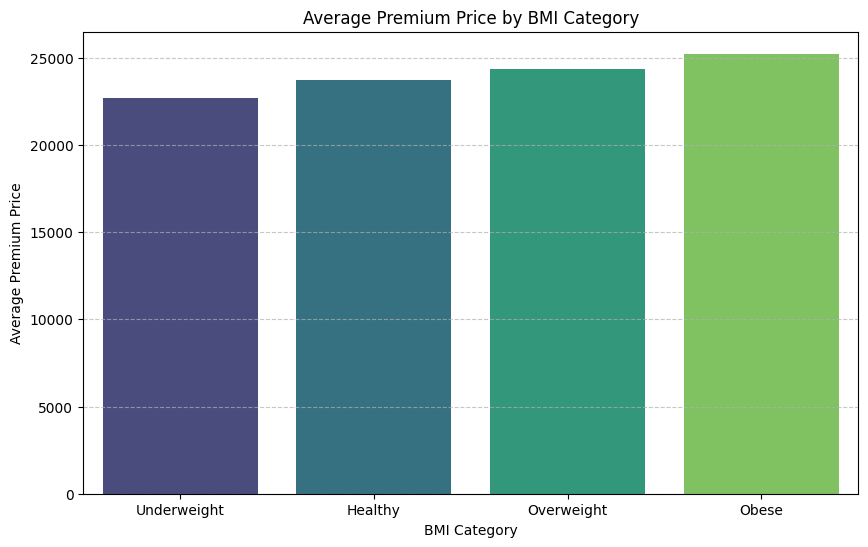

In [ ]:
# Visualize average premium price per BMI category
plt.figure(figsize=(10, 6))
sns.barplot(x='BMI_Category', y='PremiumPrice', hue='BMI_Category', data=df_bmi.groupby('BMI_Category', observed=True)['PremiumPrice'].mean().reset_index(), palette='viridis', legend=False)
plt.title('Average Premium Price by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Average Premium Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 3. Prepare groups for testing
groups = [df_bmi[df_bmi['BMI_Category'] == label]['PremiumPrice'] for label in labels]

# 4. Perform One-Way ANOVA (Parametric)
f_stat, p_val_anova = stats.f_oneway(*groups)

# 5. Perform Kruskal-Wallis (Non-Parametric)
h_stat, p_val_kruskal = stats.kruskal(*groups)

print(f"--- BMI Category Distribution ---")
print(df_bmi['BMI_Category'].value_counts())

print(f"\n--- Statistical Results ---")
print(f"ANOVA P-value: {p_val_anova:.4e}")
print(f"Kruskal-Wallis P-value: {p_val_kruskal:.4e}")

# Decision Logic
alpha = 0.05
if p_val_anova < alpha:
    print("\nConclusion (ANOVA): Reject Null Hypothesis. BMI category significantly affects Premium Price.")
else:
    print("\nConclusion (ANOVA): Fail to Reject Null Hypothesis. BMI category does not significantly affect Premium Price.")

if p_val_kruskal < alpha:
    print("Conclusion (Kruskal-Wallis): Reject Null Hypothesis. BMI category significantly affects Premium Price.")
else:
    print("Conclusion (Kruskal-Wallis): Fail to Reject Null Hypothesis. BMI category does not significantly affect Premium Price.")


--- BMI Category Distribution ---
BMI_Category
Overweight     326
Healthy        319
Obese          302
Underweight     39
Name: count, dtype: int64

--- Statistical Results ---
ANOVA P-value: 6.9496e-03
Kruskal-Wallis P-value: 1.2608e-02

Conclusion (ANOVA): Reject Null Hypothesis. BMI category significantly affects Premium Price.
Conclusion (Kruskal-Wallis): Reject Null Hypothesis. BMI category significantly affects Premium Price.


Question 7 Conclusion

Reject Null Hypothesis. BMI category significantly affects Premium Price.



Question 8
Null Hypothesis : The TotalRisk does not significantly affect the Premium Price.

Alternate Hypothesis : The TotalRisk significantly affect the Premium Price.





In [ ]:
# Perform Spearman Rank Correlation
rho, p_spearman = stats.spearmanr(df['TotalRisk'], df['PremiumPrice'])

print(f"Spearman Correlation: {rho:.4f}")
print(f"Spearman P-value: {p_spearman:.4e}")

alpha = 0.05
if p_spearman < alpha:
    print("\nConclusion: Reject Null Hypothesis. Total Risk category significantly affects Premium Price.")
else:
    print("\nConclusion: Fail to Reject Null Hypothesis. Total Risk category does not significantly affect Premium Price.")

Spearman Correlation: 0.3770
Spearman P-value: 1.1583e-34

Conclusion: Reject Null Hypothesis. Total Risk category significantly affects Premium Price.


Question 8 Conclusoin

Reject Null Hypothesis. Total Risk category significantly affects Premium Price.

#Summary of Hypothesis Testing


Question 1 Conclusion:

Reject the Null Hypothesis. There is a significant correlation between Age and Premium Price.

Question 2 Conclusion :

One-way ANOVA and Kruskal Wallis tests rejects the null hypothesis. The number of major surgeries significantly affect the Premium Price.


Question 3 Conclusion :

The two sample t test Rejected the null hypothesis. Diabetes has a significant effect on premium price.

This test has not isolated the blood pressure features weightage on the result. This test does not realize many people with diabetes also has blood pressure.

Question 4 Conclusion

Both the test rejected the null hypothesis. Therefore Blood Pressure has a significant effect on Premium Price.

Question 5 Conclusion

Fail to Reject Null Hypothesis for Diabetes: Diabetes does not significantly affect Premium Price.

This test only takes diabetes feature into its calculations.

Reject Null Hypothesis for BloodPressureProblems: Blood Pressure Problems significantly affect Premium Price.

Reject Null Hypothesis for Interaction: The interaction between Diabetes and Blood Pressure Problems significantly affects Premium Price

Question 6 Conclusion :

Reject Null Hypothesis. Chronic Disease has a significant effect on Premium Price.

Question 7 Conclusion

Reject Null Hypothesis. BMI category significantly affects Premium Price.


Question 8 Conclusoin

Reject Null Hypothesis. Total Risk category significantly affects Premium Price.






##ML Modeling
## Linear Regression

In [ ]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
#Prepare X and Y features
x = df.drop(columns=['PremiumPrice'])
y = df['PremiumPrice']

In [ ]:
# Train Test Split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state =42)

In [ ]:
# Standardization

scaler= StandardScaler()

# Fit and transform training data
x_train_scaled = scaler.fit_transform(x_train)

# Transform test data
x_test_scaled = scaler.transform(x_test)



In [ ]:
# Base Model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#Initialize and train the model

baseline_model = LinearRegression()
baseline_model.fit(x_train_scaled,y_train)

#Make Prediction

y_pred = baseline_model.predict(x_test_scaled)

# Evaluate Performance

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Baseline Model Performance (Pre-VIF) ---")
print(f"R-Squared Score : {r2 : .4f}")
print(f"Mean Absolute Error: ₹{mae:.2f}")
print(f"Root Mean Squared Error: ₹{rmse:.2f}")


--- Baseline Model Performance (Pre-VIF) ---
R-Squared Score :  0.7136
Mean Absolute Error: ₹2586.15
Root Mean Squared Error: ₹3494.40


In [ ]:
#Checking Coeficients

print(dict(zip(x.columns, baseline_model.coef_)))

{'Age': np.float64(4573.655616466642), 'Diabetes': np.float64(-273.9859975528858), 'BloodPressureProblems': np.float64(-6.171114980108939), 'AnyTransplants': np.float64(1686.2835401962755), 'AnyChronicDiseases': np.float64(921.1179305858989), 'Height': np.float64(-452.71157254217474), 'Weight': np.float64(1648.6043003423558), 'KnownAllergies': np.float64(19.135380861488592), 'HistoryOfCancerInFamily': np.float64(628.6148633277403), 'NumberOfMajorSurgeries': np.float64(-653.4555708977903), 'BMI': np.float64(-747.29028275888), 'TotalRisk': np.float64(219.54793127509555)}


In [ ]:
# Checking average of Premium Price for reviewing against baseline preformance scores

print(df['PremiumPrice'].mean())

24336.713995943206


Baseline LR Model Inference

The R-squared Score of 71% indicates that the variance in premium pricing can be explained by features of the dataset. Similarly the 29% of the errors cannot be captured from the features.

The Mean Absolute Error represent the difference in actual and predicted premium price. The model's premium price can be +/- Rs2586 for any data point.

The Root Mean Square Error penalizes large errors more than the smaller errors. The difference between MAE and RMSE (3494 - 2586 = Rs 908) shows us a large gap that could be because of outliers that pushing the RMSE value up.

To understand the variance and RMSE values we will iterate more linear regression models and evaluate with these baseline results.

In [ ]:
# Load VIF Library

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convert scaled array back to a dataframe for easier reading
x_vif = pd.DataFrame(x_train_scaled, columns=x.columns)

# Define a VIF Function

def get_vif(df_input) :
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_input.columns
    vif_data['VIF'] = [variance_inflation_factor(df_input.values, i) for i in range(len(df_input.columns))]
    return vif_data.sort_values(by = 'VIF' , ascending = False)

print(get_vif(x_vif))


                    Feature        VIF
1                  Diabetes        inf
2     BloodPressureProblems        inf
3            AnyTransplants        inf
4        AnyChronicDiseases        inf
11                TotalRisk        inf
7            KnownAllergies        inf
9    NumberOfMajorSurgeries        inf
8   HistoryOfCancerInFamily        inf
10                      BMI  85.605245
6                    Weight  64.149518
5                    Height  27.255803
0                       Age   1.355303


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


The initial ouput of my VIF scores indicates high scores and presence of multicolinearity. Total Risk feature is mathematical sum of my binary features. BMI is derived from height and weight.

Thus we will drop total risk and bmi and revaulate.

In [ ]:
# Dropping Total Risk and BMI features

x_vif_reduced = x_vif.drop(columns = ['TotalRisk','BMI'])
print(get_vif(x_vif_reduced))


                   Feature       VIF
9   NumberOfMajorSurgeries  1.369425
0                      Age  1.354404
2    BloodPressureProblems  1.112416
8  HistoryOfCancerInFamily  1.082925
1                 Diabetes  1.069214
7           KnownAllergies  1.044029
4       AnyChronicDiseases  1.015445
5                   Height  1.013504
6                   Weight  1.010637
3           AnyTransplants  1.004822


The features listed above have VIF scores les than 5. Thus we can use all these features in the ML model.

In [ ]:
# Training and Testing the model with features filterd after VIF

#Final Feature list after passing VIF
final_features = ['NumberOfMajorSurgeries', 'Age', 'BloodPressureProblems',
    'HistoryOfCancerInFamily', 'Diabetes', 'KnownAllergies',
    'AnyChronicDiseases', 'Height', 'Weight', 'AnyTransplants']

# Assuming x_train_Scaled is currently a numpy array, convert it to data frame

x_train_final = pd.DataFrame(x_train_scaled, columns = x.columns)[final_features]
x_test_final = pd.DataFrame(x_test_scaled, columns = x.columns)[final_features]


#Retrain the model
final_model = LinearRegression()
final_model.fit(x_train_final,y_train)

#Final Evaluations
y_pred = final_model.predict(x_test_final)
r2 = r2_score(y_test,y_pred)

print(f"Final Model R2 Score: {r2:.4f}")



Final Model R2 Score: 0.7134


Basline R2 score = 0.71

Final Model R2 Score = 0.71

Thus there is no difference between the two models.

We will replace Weight and height features with BMI feature and run the model again.

In [ ]:
# Create fresh features to model with BMI and without Heigh, weight

x_v2 = df.drop(columns = ['PremiumPrice', 'Height', 'Weight','TotalRisk'])

# Split data tp train and test  and then scale

x_train_v2, x_test_v2, y_train, y_test = train_test_split(x_v2,y,test_size=0.2,random_state=42)

#Scale
scaler_v2 = StandardScaler()
x_train_scaled_v2 = scaler_v2.fit_transform(x_train_v2)
x_test_scaled_v2 = scaler_v2.transform(x_test_v2)

# Scheck VIF scores on new list
x_vif_check = pd.DataFrame(x_train_scaled_v2, columns = x_v2.columns)
print(get_vif(x_vif_check))



                   Feature       VIF
7   NumberOfMajorSurgeries  1.365739
0                      Age  1.354797
2    BloodPressureProblems  1.104770
6  HistoryOfCancerInFamily  1.082637
1                 Diabetes  1.068638
5           KnownAllergies  1.043785
4       AnyChronicDiseases  1.015469
8                      BMI  1.007803
3           AnyTransplants  1.003897


In [ ]:
# Run the Final Regression model

#Initialize and Train the model using the BMI-based scaled data
bmi_model = LinearRegression()
bmi_model.fit(x_train_scaled_v2, y_train)

#Predict on the test set
y_pred_v2 = bmi_model.predict(x_test_scaled_v2)

#Final Evaluation
r2_v2 = r2_score(y_test, y_pred_v2)
mae_v2 = mean_absolute_error(y_test, y_pred_v2)

print(f"--- BMI Model Results ---")
print(f"Final R2 Score: {r2_v2:.4f}")
print(f"Mean Absolute Error: ₹{mae_v2:.2f}")

# Check the "Weight" of each feature
coefficients = pd.DataFrame({'Feature': x_v2.columns, 'Importance': bmi_model.coef_})
print("\nFeature Importance (Coefficients):")
print(coefficients.sort_values(by='Importance', ascending=False))




--- BMI Model Results ---
Final R2 Score: 0.7078
Mean Absolute Error: ₹2629.69

Feature Importance (Coefficients):
                   Feature   Importance
0                      Age  4576.348992
3           AnyTransplants  1701.498440
4       AnyChronicDiseases   986.746145
8                      BMI   843.349909
6  HistoryOfCancerInFamily   677.028848
5           KnownAllergies    68.955969
2    BloodPressureProblems    41.537274
1                 Diabetes  -180.496243
7   NumberOfMajorSurgeries  -504.189052


Linear Regression Inference

The model was run on three versions of the dataframe.

1. Baseline Model with all the features :

    R2 metric = 0.71


2. Model without BMI and Total Risk features :

    R2 metric = 0.71

3. Model without Total Risk, Height and Weight features :

    R2 Metric = 0.70


These R2 performancne metrics suggests the 0.71 could be the ceiling for the linear regression model. This model saturation proves the limitation is the algorithm and not the data.

Another point to note is the weightage that was achieved by the model for all features. Many of them were not correct. For example, number of major surgeries has a coeeficient of -504. This means the premium would reduce by Rs504 for every unit of the feature. But the hypothesis testing and the business suggests the premium will only be positive when a surgery is performed.

These outcomes indicate the dataset is not linear in nature. We will need to investigate other models - Decision Tree, Random Forest and Gradient boosting to achieve a higher R2 Score.

# Decision Trees

In [ ]:
# initialize and train
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# set a max_depth to prevent the tree from becoming a giant, unreadable mess
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(x_train_scaled_v2, y_train)

# Predict and Evaluate
y_pred_dt = dt_model.predict(x_test_scaled_v2)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"--- Decision Tree Results ---")
print(f"R2 Score: {r2_dt:.4f}")

--- Decision Tree Results ---
R2 Score: 0.8088



Feature Importance (Tree-based):
                   Feature  Importance
0                      Age    0.732554
3           AnyTransplants    0.118840
8                      BMI    0.053549
4       AnyChronicDiseases    0.035358
7   NumberOfMajorSurgeries    0.033990
6  HistoryOfCancerInFamily    0.022802
2    BloodPressureProblems    0.002907
1                 Diabetes    0.000000
5           KnownAllergies    0.000000


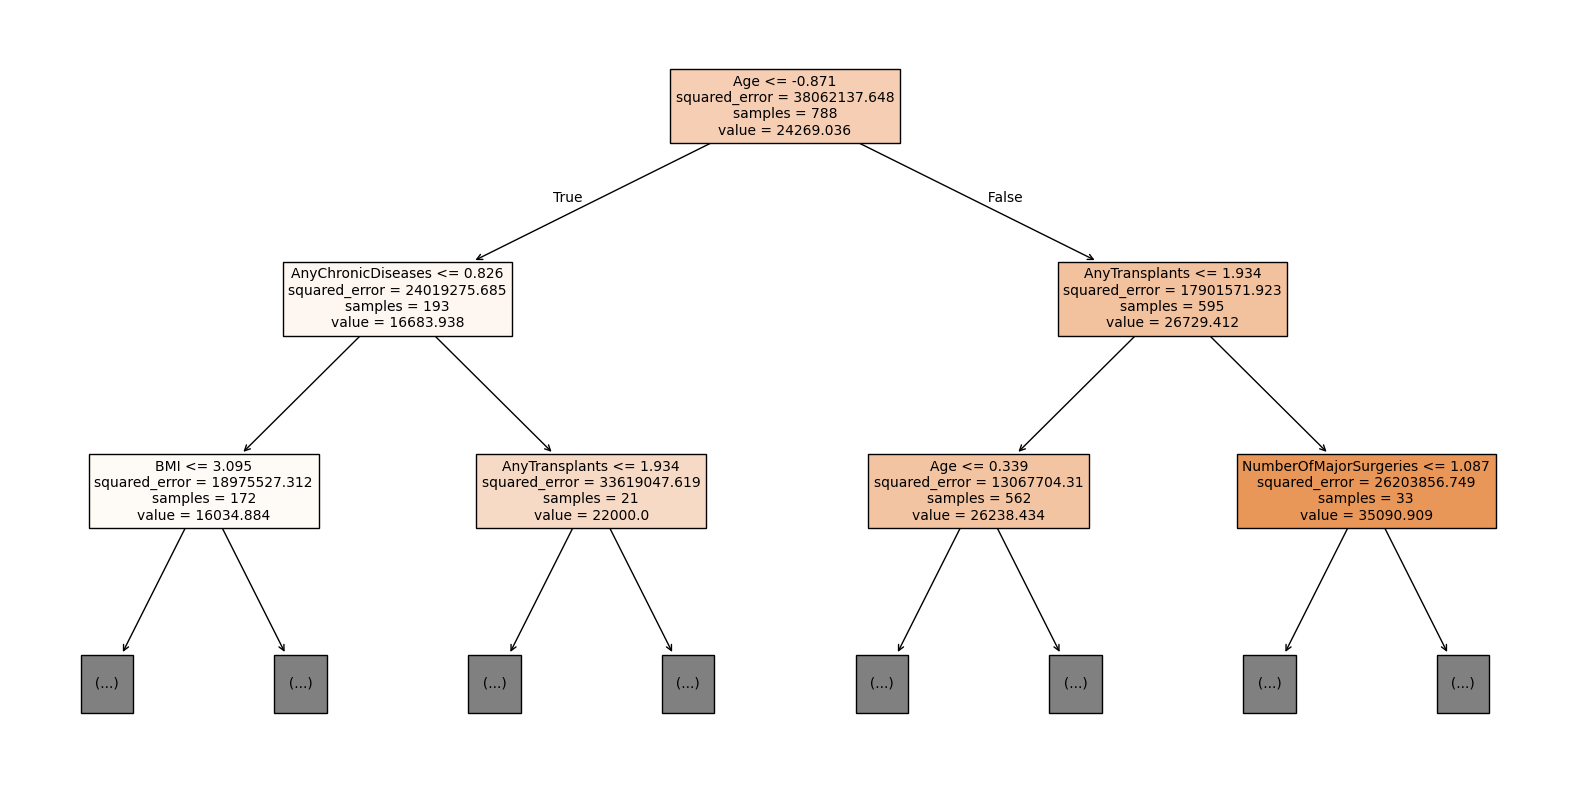

In [ ]:
#Check the logic (Feature Importance)
dt_importance = pd.DataFrame({'Feature': x_v2.columns, 'Importance': dt_model.coef_ if hasattr(dt_model, 'coef_') else dt_model.feature_importances_})
print("\nFeature Importance (Tree-based):")
print(dt_importance.sort_values(by='Importance', ascending=False))

# Visualize the first few levels of the logic
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=x_v2.columns, filled=True, max_depth=2, fontsize=10)
plt.show()

The model has gone over the 71% performance to 81%. This confirms are hypothesis that the insurance pricing is non linear. The model identifies Age and Any Transplants as the highest risk drivers.

The 0% in feature importance for diabetes and allergies does not mean they dont influence the price. It indicates that the model has factored the weightage from other features. The decision tree thus found age and allergies redundant.

#Random Forest

In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

# Initialize and Train
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(x_train_scaled_v2, y_train)

#  Predict and Evaluate
y_pred_rf = rf_model.predict(x_test_scaled_v2)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"--- Random Forest Results ---")
print(f"R2 Score: {r2_rf:.4f}")

# Feature Importance
rf_importance = pd.DataFrame({'Feature': x_v2.columns, 'Importance': rf_model.feature_importances_})
print("\nFeature Importance (Random Forest):")
print(rf_importance.sort_values(by='Importance', ascending=False))

--- Random Forest Results ---
R2 Score: 0.8642

Feature Importance (Random Forest):
                   Feature  Importance
0                      Age    0.638003
8                      BMI    0.148231
3           AnyTransplants    0.096783
4       AnyChronicDiseases    0.039122
7   NumberOfMajorSurgeries    0.031017
6  HistoryOfCancerInFamily    0.022583
2    BloodPressureProblems    0.010074
1                 Diabetes    0.008408
5           KnownAllergies    0.005779


In [ ]:
from sklearn.metrics import mean_absolute_error
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest MAE: ₹{mae_rf:.2f}")

Random Forest MAE: ₹1432.20


Random Forest Inference

The model has captured 86% of factors that are influencing premium pricing. There is reduction in Mean absolute error to Rs1432. This is large difference between this value to the linear model value of Rs2586. This indicates the model has improved by 45% in prediction.

There is also a slight change in the feature importance table. The diabetes and allergies features have also been captured in this model, even though it has low values. It means the model is picking up subtle risks.

# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the "Heavy Lifter"
# Learning_rate and n_estimators are the key knobs here
gbr_model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)

# Train
gbr_model.fit(x_train_scaled_v2, y_train)

# Predict and Evaluate
y_pred_gbr = gbr_model.predict(x_test_scaled_v2)
r2_gbr = r2_score(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

print(f"--- Gradient Boosting Results ---")
print(f"R2 Score: {r2_gbr:.4f}")
print(f"MAE: ₹{mae_gbr:.2f}")

--- Gradient Boosting Results ---
R2 Score: 0.8278
MAE: ₹1722.88


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the "Grid" of parameters to test
param_grid = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0] # Helps prevent overfitting
}

# Set up the Search
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1 # Use all CPU cores
)

# Run the search
grid_search.fit(x_train_scaled_v2, y_train)

# See the results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R2 Score: {grid_search.best_score_:.4f}")

# Evaluate the best model on your test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(x_test_scaled_v2)
print(f"Final Test R2: {r2_score(y_test, y_pred_best):.4f}")

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Best CV R2 Score: 0.6965
Final Test R2: 0.8509


Gradient Boosting Inference

Gradient boosting is supposed to be a optimizer, i.e it tries to fix mistakes of the previous trees. But in this case, the performance is weaker at 82% compared with random forest's 86%.

The cross validation score is significantly lesser at 69%. The gap between CV score and R2 score shows a red flag and thus we will use random forest as our final model for Premium Price Prediction.

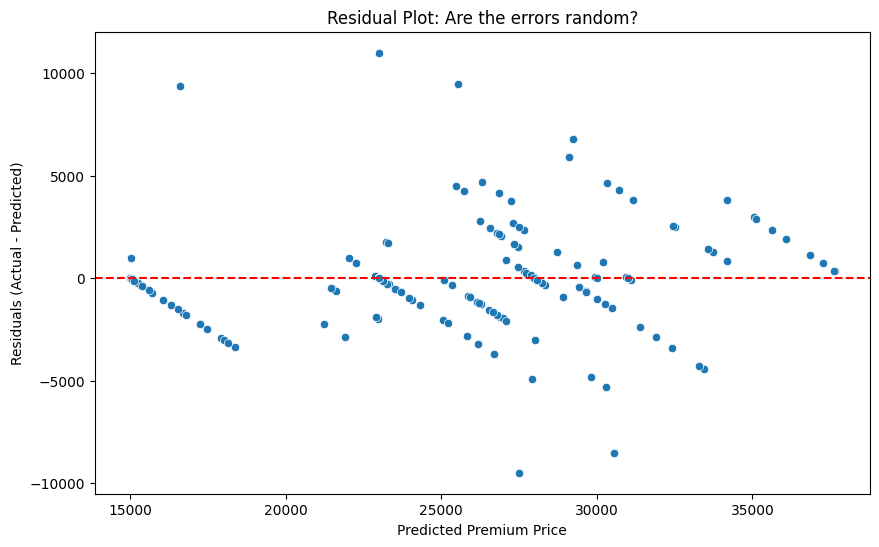

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using your best model (Random Forest)
residuals = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot: Are the errors random?')
plt.xlabel('Predicted Premium Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

1. The "Age-Risk" Compounder
Insight: Age is the primary engine of cost (63.8% importance). However, the move from Linear to Tree models proved that this risk doesn't grow in a straight line; it accelerates significantly after specific age thresholds.

Actionable Intervention: Develop "Age-Bracketed Wellness Incentives." Instead of a generic yearly increase, create targeted health-check subsidies for customers hitting 45 and 55, where the model shows the steepest premium "jumps."

2. BMI as a "Secondary Multiplier"
Insight: At 14.8% importance, BMI is the second most reliable predictor. The model suggests that BMI acts as a "multiplier" for other conditions. A high BMI combined with a chronic disease isn't just an addition of two risks—it’s an exponential increase.

Actionable Intervention: Launch "Weight Management Rebates." Since BMI is a modifiable risk factor, offering premium discounts for customers who maintain or improve their BMI within a healthy range directly reduces the company's financial exposure.

3. The "High-Severity" Filter (Transplants)
Insight: Any history of transplants (9.6%) is a high-impact "binary" trigger. The model correctly identifies this as a massive, non-negotiable price driver that overrides almost all other minor health factors.

Actionable Intervention: Implement "Automated High-Risk Underwriting." Use the model to flag transplant cases for immediate specialized review. Since the model is highly accurate on these "sharp" risk factors, you can automate standard quotes while reserving human experts for these high-cost outliers.

4. Addressing "Hidden" Chronic Risks
Insight: While Diabetes and Allergies showed low importance in isolation, they serve as "early warning" signals in the Random Forest logic.

Actionable Intervention: Create "Pre-emptive Care Packages." Since the model uses these features to "fine-tune" the price, the business can use them to identify customers who are one step away from a more expensive "Major Chronic Disease" category